## Medical Image Processing - Final Project: Brain Tumor Classification

### Ran Uram- 206661886
### Shaked Rosenberg- 209547033


## Uncomment to install libraries if needed

In [ ]:
!pip install -q kaggle imagehash Pillow scikit-learn tensorflow gdown numpy pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 7.8 MB/s eta 0:00:00


In [ ]:
# Standard Library Imports
import os
import glob
import shutil
import random
import subprocess
import hashlib
import time
from collections import defaultdict, Counter
from concurrent.futures import ThreadPoolExecutor, as_completed

# Third-Party Library Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import imagehash
import gdown

# TensorFlow/Keras Imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization, Flatten, Dense, Dropout, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import DenseNet121, EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

# Scikit-learn Imports
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import gc


In [ ]:

data_dir = './data'
if os.path.exists(data_dir):
    print("Clearing old data from disk...")
    shutil.rmtree(data_dir)
os.makedirs(data_dir, exist_ok=True)

file_id = "1Aaofa1wC2jGlLmWiCyNhUP1dr5vNdH7R"
zip_path = "./data/all_datasets.zip"

print("Downloading zip from Google Drive...")
gdown.download(id=file_id, output=zip_path, quiet=False, fuzzy=True)

print("Extracting...")
shutil.unpack_archive(zip_path, data_dir)
os.remove(zip_path)

# Rename extracted folders to a consistent naming convention
rename_map = {
    "Brain Cancer - MRI dataset": "brain_cancer_mri_dataset",
    "Brain Tumor MRI Multi-Class Dataset": "brain_tumor_mri_multi_class_dataset",
    "BrainTumorDataset": "brain_tumor_dataset",
}

for old_name, new_name in rename_map.items():
    old_path = os.path.join(data_dir, old_name)
    new_path = os.path.join(data_dir, new_name)
    if os.path.exists(old_path):
        os.rename(old_path, new_path)
        print(f"Renamed: {old_name} -> {new_name}")
    else:
        print(f"Warning: expected folder not found: {old_name}")

print("Done. Contents of ./data:")
print(os.listdir(data_dir))

Downloading...
From (original): https://drive.google.com/uc?id=1Aaofa1wC2jGlLmWiCyNhUP1dr5vNdH7R
From (redirected): https://drive.google.com/uc?id=1Aaofa1wC2jGlLmWiCyNhUP1dr5vNdH7R&confirm=t&uuid=912a7d95-0a65-4ee8-a957-8595bdebffeb
To: /content/data/all_datasets.zip
100%|██████████| 1.55G/1.55G [00:27<00:00, 56.6MB/s]


Extracting...
Renamed: Brain Cancer - MRI dataset -> brain_cancer_mri_dataset
Renamed: Brain Tumor MRI Multi-Class Dataset -> brain_tumor_mri_multi_class_dataset
Renamed: BrainTumorDataset -> brain_tumor_dataset
Done. Contents of ./data:
['brain_tumor_mri_multi_class_dataset', 'brain_tumor_dataset', 'brain_cancer_mri_dataset']


Found 32879 images. Computing hashes in parallel...
Hashing complete. Deduplicating...
Unique images by class:
  glioma: 6331
  meningioma: 4872
  notumor: 5015
  pituitary: 2761
Total: 18979
Duplicate sets found: 6658


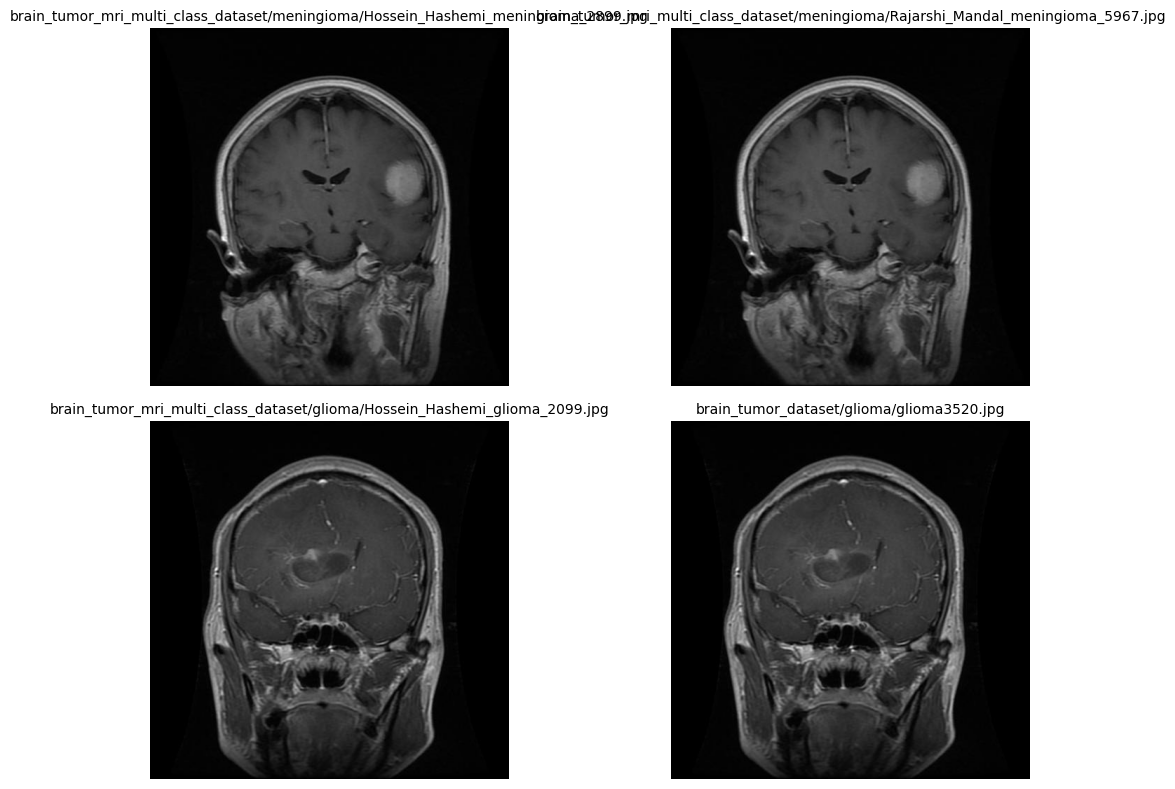

In [ ]:
FOLDER_TO_CLASS = {
    'glioma':       'glioma',
    'brain_glioma': 'glioma',
    'meningioma':   'meningioma',
    'brain_menin':  'meningioma',
    'no_tumor':     'notumor',
    'healthy':      'notumor',
    'pituitary':    'pituitary',
}

all_images = glob.glob('./data/**/*.jpg', recursive=True) + \
             glob.glob('./data/**/*.png', recursive=True) + \
             glob.glob('./data/**/*.jpeg', recursive=True)

print(f"Found {len(all_images)} images. Computing hashes in parallel...")

def process_image(img_path):
    folder_name = os.path.basename(os.path.dirname(img_path)).lower()
    target_class = FOLDER_TO_CLASS.get(folder_name)
    if target_class is None:
        return None
    try:
        with Image.open(img_path) as img:
            file_hash = str(imagehash.phash(img))
        return (img_path, target_class, file_hash)
    except Exception as e:
        print(f"Error: {e}")
        return None

results = []
with ThreadPoolExecutor(max_workers=8) as executor:
    futures = {executor.submit(process_image, p): p for p in all_images}
    for future in as_completed(futures):
        result = future.result()
        if result:
            results.append(result)

print(f"Hashing complete. Deduplicating...")

classes_data = {'glioma': [], 'meningioma': [], 'notumor': [], 'pituitary': []}
seen_hashes = set()
hash_to_paths = defaultdict(list)

for img_path, target_class, file_hash in results:
    hash_to_paths[file_hash].append(img_path)
    if file_hash not in seen_hashes:
        classes_data[target_class].append(img_path)
        seen_hashes.add(file_hash)

print(f"Unique images by class:")
for cls, paths in classes_data.items():
    print(f"  {cls}: {len(paths)}")
print(f"Total: {sum(len(p) for p in classes_data.values())}")

duplicates = {h: paths for h, paths in hash_to_paths.items() if len(paths) > 1}
print(f"Duplicate sets found: {len(duplicates)}")

if duplicates:
    sample_hashes = random.sample(list(duplicates.keys()), min(2, len(duplicates)))
    fig, axes = plt.subplots(len(sample_hashes), 2, figsize=(12, 4 * len(sample_hashes)))
    if len(sample_hashes) == 1:
        axes = [axes]
    for idx, h in enumerate(sample_hashes):
        for col, path in enumerate(duplicates[h][:2]):
            try:
                axes[idx][col].imshow(Image.open(path), cmap='gray')
                axes[idx][col].set_title("/".join(path.split('/')[-3:]), fontsize=10)
                axes[idx][col].axis('off')
            except Exception:
                axes[idx][col].set_title("Load error")
                axes[idx][col].axis('off')
    plt.tight_layout()
    plt.show()

### Unique Resolutions and Shapes

In [ ]:


resolutions = []
for class_name, paths in classes_data.items():
    for img_path in paths:
        try:
            with Image.open(img_path) as img:
                resolutions.append(img.size)
        except Exception:
            continue

resolution_counts = Counter(resolutions)
print(f"Total unique resolutions: {len(resolution_counts)}")
print("\nTop 20 most common resolutions:")
for res, count in resolution_counts.most_common(20):
    print(f"  {res[0]}x{res[1]}: {count} images")

Total unique resolutions: 446

Top 20 most common resolutions:
  512x512: 15467 images
  256x256: 1445 images
  630x630: 383 images
  225x225: 187 images
  224x224: 138 images
  400x539: 64 images
  549x630: 37 images
  200x252: 29 images
  442x442: 27 images
  150x198: 27 images
  300x168: 27 images
  192x192: 26 images
  232x217: 25 images
  236x236: 24 images
  201x251: 24 images
  533x630: 23 images
  228x221: 22 images
  571x630: 21 images
  206x244: 20 images
  512x630: 18 images


## checking the most common color format (RGB, Grayscale...)

In [ ]:
modes = []
for class_name, paths in classes_data.items():
    for img_path in paths:
        try:
            with Image.open(img_path) as img:
                modes.append(img.mode)
        except Exception:
            continue

mode_counts = Counter(modes)
print("Top 3 most common color formats:")
for mode, count in mode_counts.most_common(3):
    print(f"  {mode}: {count} images")

Top 3 most common color formats:
  RGB: 11989 images
  L: 4191 images
  RGBA: 2799 images


## Data Splits

There are two data splits used in this notebook:
-   A "main" split, encompassing all classes with their natural imbalance. This split is used by Models 1, 2, 3, 5, 6, 7, and 8.
-   A separate "balanced" split, which was created by undersampling the larger classes to match the count of the smallest class (pituitary). This split is exclusively used by Model 4 to test undersampling as an alternative to class weighting.

In [ ]:
class_to_label = {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
all_paths, all_labels = [], []

for class_name, paths in classes_data.items():
    for p in paths:
        all_paths.append(p)
        all_labels.append(class_to_label[class_name])

all_paths = np.array(all_paths)
all_labels = np.array(all_labels)

# --- Main Data Split (used by Models 1, 2, 3, 4, 5, 6, 7) ---
# Split into training (64%), validation (16%), and test (20%)
X_train_paths_main_temp, X_test_paths_main, y_train_main_temp, y_test_main = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)
X_train_paths_main, X_val_paths_main, y_train_main, y_val_main = train_test_split(
    X_train_paths_main_temp, y_train_main_temp, test_size=0.2, random_state=42, stratify=y_train_main_temp
)

print(f"\nMain Split Sizes:")
print(f"  Training set: {len(X_train_paths_main)}")
print(f"  Validation set: {len(X_val_paths_main)}")
print(f"  Test set: {len(X_test_paths_main)}")

# --- Balanced Data Split (used only by Model 8) ---
pituitary_count = len(classes_data['pituitary'])

balanced_paths = []
balanced_labels = []

for class_name, paths in classes_data.items():
    label = class_to_label[class_name]
    random.shuffle(paths) # Shuffle paths to ensure random selection
    sampled_paths = paths[:pituitary_count] # Take a maximum of pituitary_count images
    balanced_paths.extend(sampled_paths)
    balanced_labels.extend([label] * len(sampled_paths))

balanced_paths = np.array(balanced_paths)
balanced_labels = np.array(balanced_labels)

X_train_paths_balanced_temp, X_test_paths_balanced, y_train_balanced_temp, y_test_balanced = train_test_split(
    balanced_paths, balanced_labels, test_size=0.2, random_state=42, stratify=balanced_labels
)
X_train_paths_balanced, X_val_paths_balanced, y_train_balanced, y_val_balanced = train_test_split(
    X_train_paths_balanced_temp, y_train_balanced_temp, test_size=0.2, random_state=42, stratify=y_train_balanced_temp
)

print(f"\nBalanced Split Sizes (for Model 4):")
print(f"  Training set: {len(X_train_paths_balanced)}")
print(f"  Validation set: {len(X_val_paths_balanced)}")
print(f"  Test set: {len(X_test_paths_balanced)}")


Main Split Sizes:
  Training set: 12146
  Validation set: 3037
  Test set: 3796

Balanced Split Sizes (for Model 4):
  Training set: 7068
  Validation set: 1767
  Test set: 2209


### Image Normalization and Data Preparation for CNN

In [ ]:

TARGET_SIZE = (256, 256)
NUM_CLASSES = 4
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=1, expand_animations=False)
    img = tf.image.resize(img, TARGET_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    return image, label

def augment_pituitary(image, label):
    is_pituitary = tf.equal(tf.argmax(label), 3)
    image = tf.cond(is_pituitary,
                    lambda: augment(image, label)[0],
                    lambda: image)
    return image, label

def make_dataset(paths, labels, shuffle=False, augment_data=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
        ds = ds.map(augment_pituitary, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

# Updated to use the _main suffixed split variables from cell 4c2dcb48
train_ds= make_dataset(X_train_paths_main, y_train_main, shuffle=True, augment_data=True)
validation_ds = make_dataset(X_val_paths_main, y_val_main, shuffle=False)
test_ds= make_dataset(X_test_paths_main, y_test_main, shuffle=False)

## Model 1: Baseline CNN, Learning Rate 0.0001

This model establishes the baseline for the from-scratch CNN architecture: four convolutional blocks (each followed by Batch Normalization and Max Pooling), a Flatten layer, a 256-neuron Dense layer with Dropout, and a Softmax output. It is trained on the full, naturally imbalanced dataset at 256×256 resolution, using standard class weights (Pituitary weighted 2.0) and the pituitary-specific double-augmentation cycle to address the underrepresentation of that class. The learning rate is set to 0.0001, with an Early Stopping callback (patience 5) monitoring validation loss to prevent overfitting.

In [ ]:
model1 = Sequential()

model1.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(256,256,1)))
model1.add(BatchNormalization())
model1.add(MaxPooling2D((2,2)))

model1.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model1.add(BatchNormalization())
model1.add(MaxPooling2D((2,2)))

model1.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model1.add(BatchNormalization())
model1.add(MaxPooling2D((2,2)))

model1.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model1.add(BatchNormalization())
model1.add(MaxPooling2D((2,2)))
model1.add(Flatten())
model1.add(Dense(256, activation='relu'))
model1.add(Dropout(0.5))
model1.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#since pituitary have the least amount of photos during in the data, we punish the model more for mistaking it
class_weight_dict_standard = {
    0: 1.0,  # glioma
    1: 1.0,  # meningioma
    2: 1.0,  # notumor
    3: 2.0   # pituitary
}

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
model1.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

start_time1 = time.time()
history1 = model1.fit(train_ds, epochs=30, validation_data=validation_ds,class_weight=class_weight_dict_standard,callbacks=[early_stop])
end_time1 = time.time()
training_time1 = (end_time1 - start_time1) / 60  # Convert to minutes
print(f"Model 1 training time: {training_time1:.3f} minutes")

Epoch 1/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 66s 137ms/step - accuracy: 0.6260 - loss: 1.1008 - val_accuracy: 0.3533 - val_loss: 4.4960
Epoch 2/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 62s 111ms/step - accuracy: 0.7280 - loss: 0.6774 - val_accuracy: 0.7698 - val_loss: 0.5112
Epoch 3/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 80s 107ms/step - accuracy: 0.7913 - loss: 0.5403 - val_accuracy: 0.8107 - val_loss: 0.4189
Epoch 4/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 40s 105ms/step - accuracy: 0.8290 - loss: 0.4288 - val_accuracy: 0.8726 - val_loss: 0.3377
Epoch 5/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 43s 110ms/step - accuracy: 0.8557 - loss: 0.3859 - val_accuracy: 0.8107 - val_loss: 0.5187
Epoch 6/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 45s 119ms/step - accuracy: 0.8770 - loss: 0.3259 - val_accuracy: 0.9048 - val_loss: 0.2556
Epoch 7/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 40s 106ms/step - accuracy: 0.8814 - loss: 0.3060 - val_accuracy: 0.9147 - val_loss: 0.2350
Epoch 8/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 40s 106ms/step - accuracy: 0.9066 - loss: 0

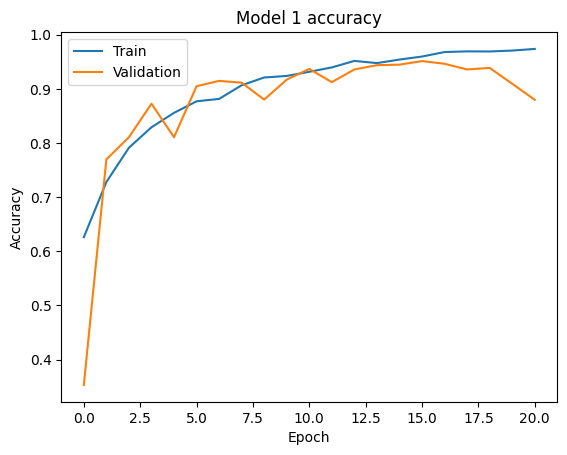

In [ ]:

# Plot training & validation accuracy values
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.title('Model 1 accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

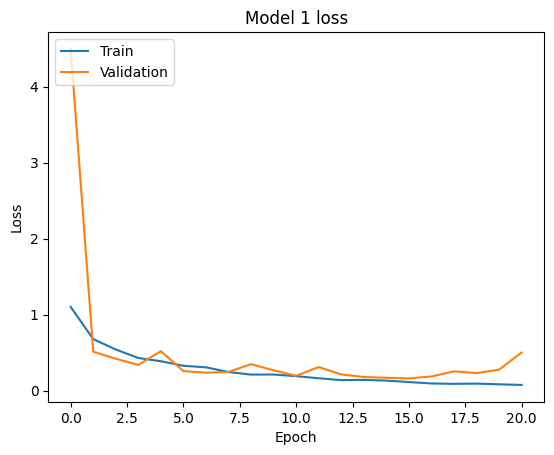

In [ ]:

#plotting train & validation loss
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.title('Model 1 loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

In [ ]:
val_predictions1 = model1.predict(validation_ds)
val_predicted_classes1 = np.argmax(val_predictions1, axis=1)
val_true_classes1 = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in validation_ds])

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
print(classification_report(val_true_classes1, val_predicted_classes1, target_names=class_names))

95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step
              precision    recall  f1-score   support

      glioma       0.97      0.92      0.95      1013
  meningioma       0.90      0.95      0.92       779
     notumor       0.95      0.97      0.96       803
   pituitary       0.99      0.99      0.99       442

    accuracy                           0.95      3037
   macro avg       0.95      0.96      0.96      3037
weighted avg       0.95      0.95      0.95      3037



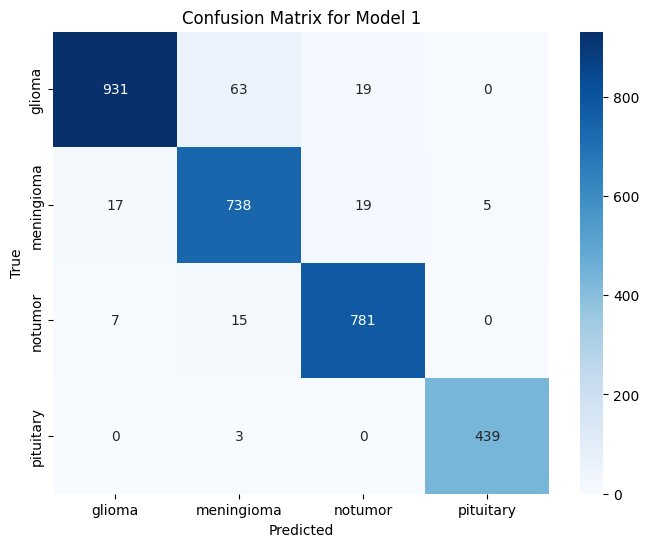

In [ ]:
cm1 = confusion_matrix(val_true_classes1, val_predicted_classes1)
plt.figure(figsize=(8, 6))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Model 1')
plt.show()

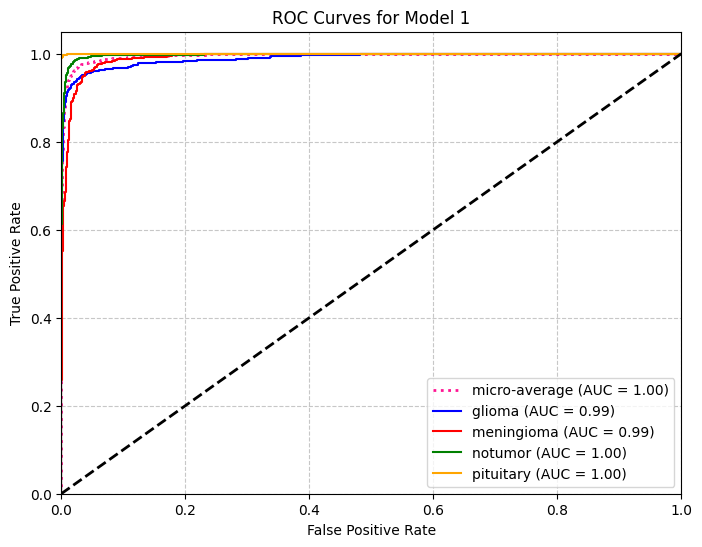

In [ ]:
# Model 1 ROC/AUC


class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(class_names)

# True labels and prediction probabilities for Model 1 (using val_true_classes from previous cells)
y_true = val_true_classes1
y_pred_proba = val_predictions1

# Binarize true labels for one-vs-rest ROC
y_true_binarized = label_binarize(y_true, classes=range(NUM_CLASSES))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot all ROC curves
plt.figure(figsize=(8, 6))

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=2)

# Plot individual class ROC curves
colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Plot random chance line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Model 1')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Model 2: Lower Learning Rate and Stricter Early Stopping

During initial testing of Model 1, minor instabilities were observed in the validation accuracy curve. Model 2 reuses the identical baseline CNN architecture, class weights, and pituitary double-augmentation strategy, but tests whether a more granular convergence improves generalization by reducing the learning rate to 0.00005 and tightening the Early Stopping patience to 3 epochs.

In [ ]:
model2 = Sequential()

model2.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(256,256,1)))
model2.add(BatchNormalization())
model2.add(MaxPooling2D((2,2)))

model2.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model2.add(BatchNormalization())
model2.add(MaxPooling2D((2,2)))

model2.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model2.add(BatchNormalization())
model2.add(MaxPooling2D((2,2)))

model2.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model2.add(BatchNormalization())
model2.add(MaxPooling2D((2,2)))
model2.add(Flatten())
model2.add(Dense(256, activation='relu'))
model2.add(Dropout(0.5))
model2.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 256, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    16,777,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,168,260 (65.49 MB)

 Trainable params: 17,167,300 (65.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
model2.compile(optimizer=Adam(learning_rate=0.00005), loss='categorical_crossentropy', metrics=['accuracy'])

start_time2 = time.time()
history2 = model2.fit(train_ds, epochs=30, validation_data=validation_ds,class_weight=class_weight_dict_standard,callbacks=[early_stop])
end_time2 = time.time()
training_time2 = (end_time2 - start_time2) / 60  # Convert to minutes
print(f"Model 2 training time: {training_time2:.3f} minutes")

Epoch 1/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 54s 124ms/step - accuracy: 0.6560 - loss: 0.9788 - val_accuracy: 0.3645 - val_loss: 3.0833
Epoch 2/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 41s 107ms/step - accuracy: 0.7658 - loss: 0.6020 - val_accuracy: 0.8291 - val_loss: 0.3988
Epoch 3/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 46s 120ms/step - accuracy: 0.8189 - loss: 0.4704 - val_accuracy: 0.8624 - val_loss: 0.3217
Epoch 4/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 45s 119ms/step - accuracy: 0.8500 - loss: 0.3853 - val_accuracy: 0.8383 - val_loss: 0.3688
Epoch 5/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 40s 106ms/step - accuracy: 0.8735 - loss: 0.3276 - val_accuracy: 0.8666 - val_loss: 0.3075
Epoch 6/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 40s 106ms/step - accuracy: 0.8970 - loss: 0.2720 - val_accuracy: 0.8584 - val_loss: 0.3572
Epoch 7/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 43s 110ms/step - accuracy: 0.9117 - loss: 0.2252 - val_accuracy: 0.9269 - val_loss: 0.1986
Epoch 8/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 86s 120ms/step - accuracy: 0.9243 - loss: 0

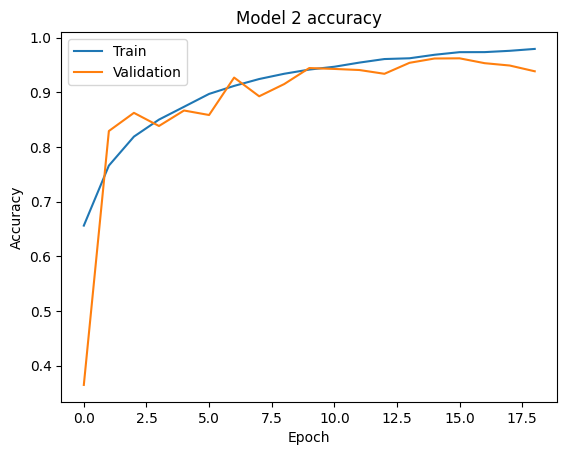

In [ ]:

# Plot training & validation accuracy values
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title('Model 2 accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

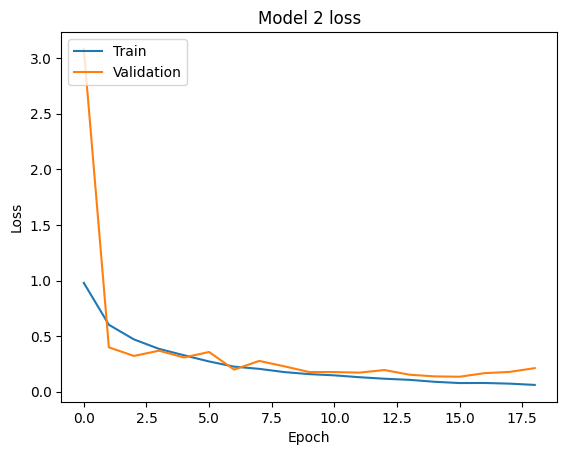

In [ ]:

#plotting train & validation loss
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('Model 2 loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

In [ ]:
val_predictions2 = model2.predict(validation_ds)
val_predicted_classes2 = np.argmax(val_predictions2, axis=1)
val_true_classes2 = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in validation_ds])

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
print(classification_report(val_true_classes2, val_predicted_classes2, target_names=class_names))

95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step
              precision    recall  f1-score   support

      glioma       0.97      0.95      0.96      1013
  meningioma       0.93      0.95      0.94       779
     notumor       0.96      0.98      0.97       803
   pituitary       1.00      1.00      1.00       442

    accuracy                           0.96      3037
   macro avg       0.97      0.97      0.97      3037
weighted avg       0.96      0.96      0.96      3037



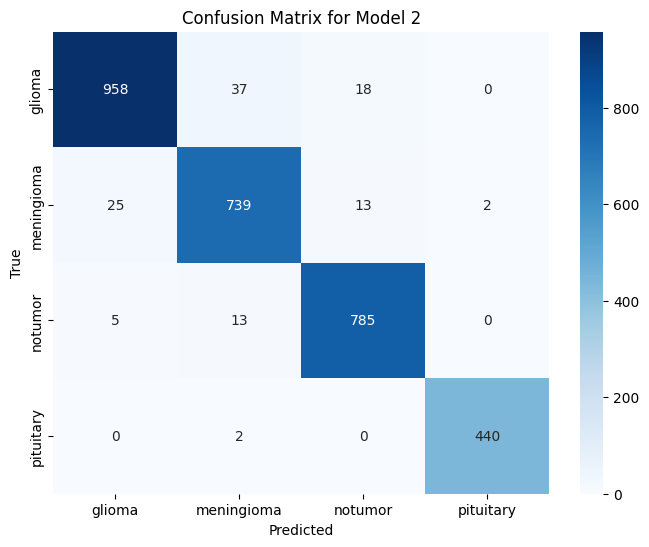

In [ ]:
cm2 = confusion_matrix(val_true_classes2, val_predicted_classes2)
plt.figure(figsize=(8, 6))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Model 2')
plt.show()

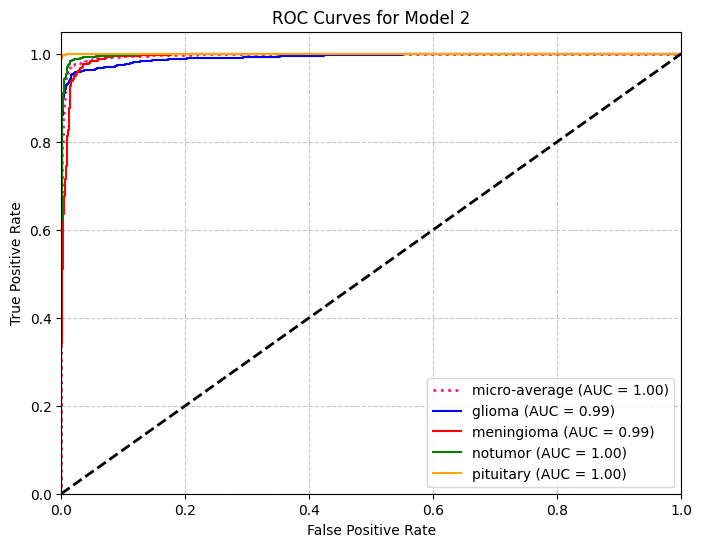

In [ ]:
# Model 2 ROC/AUC


class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(class_names)

# True labels and prediction probabilities for Model 2 (using val_true_classes from previous cells)
y_true = val_true_classes2
y_pred_proba = val_predictions2

# Binarize true labels for one-vs-rest ROC
y_true_binarized = label_binarize(y_true, classes=range(NUM_CLASSES))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot all ROC curves
plt.figure(figsize=(8, 6))

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=2)

# Plot individual class ROC curves
colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Plot random chance line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Model 2')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Model 3: Extending Class Weighting to Meningioma

Model 3 reuses the same baseline CNN architecture as Models 1 and 2, with the learning rate returned to 0.0001 and Early Stopping patience of 5, matching Model 1's configuration. It tests an alternative class-weighting strategy: in addition to the existing 2.0 weight multiplier for Pituitary, Meningioma is assigned a 1.5 weight multiplier, based on the hypothesis that its more heterogeneous visual presentation may also benefit from increased training emphasis.

In [ ]:
#since pituitary have the least amount of photos during in the data, we punish the model more for mistaking it
class_weight_dict_model3 = {
    0: 1.0,  # glioma
    1: 1.5,  # meningioma
    2: 1.0,  # notumor
    3: 2.0   # pituitary
}

In [ ]:
model3 = Sequential()

model3.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(256,256,1)))
model3.add(BatchNormalization())
model3.add(MaxPooling2D((2,2)))

model3.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model3.add(BatchNormalization())
model3.add(MaxPooling2D((2,2)))

model3.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model3.add(BatchNormalization())
model3.add(MaxPooling2D((2,2)))

model3.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model3.add(BatchNormalization())
model3.add(MaxPooling2D((2,2)))
model3.add(Flatten())
model3.add(Dense(256, activation='relu'))
model3.add(Dropout(0.5))
model3.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
model3.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

start_time3 = time.time()
history3 = model3.fit(train_ds, epochs=30, validation_data=validation_ds,class_weight=class_weight_dict_model3,callbacks=[early_stop])
end_time3 = time.time()
training_time3 = (end_time3 - start_time3) / 60  # Convert to minutes
print(f"Model 3 training time: {training_time3:.3f} minutes")

Epoch 1/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 57s 130ms/step - accuracy: 0.6167 - loss: 1.2881 - val_accuracy: 0.3773 - val_loss: 4.1707
Epoch 2/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 41s 107ms/step - accuracy: 0.7262 - loss: 0.7989 - val_accuracy: 0.7277 - val_loss: 0.5605
Epoch 3/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 46s 120ms/step - accuracy: 0.7903 - loss: 0.6282 - val_accuracy: 0.8288 - val_loss: 0.4081
Epoch 4/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 42s 109ms/step - accuracy: 0.8305 - loss: 0.5104 - val_accuracy: 0.8367 - val_loss: 0.3836
Epoch 5/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 82s 108ms/step - accuracy: 0.8483 - loss: 0.4564 - val_accuracy: 0.9025 - val_loss: 0.2676
Epoch 6/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 46s 120ms/step - accuracy: 0.8778 - loss: 0.3785 - val_accuracy: 0.8439 - val_loss: 0.3484
Epoch 7/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 46s 120ms/step - accuracy: 0.8893 - loss: 0.3462 - val_accuracy: 0.9055 - val_loss: 0.2420
Epoch 8/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 45s 119ms/step - accuracy: 0.9074 - loss: 0

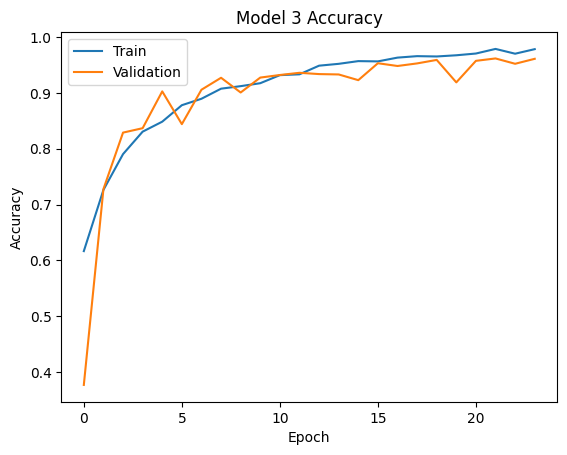

In [ ]:

# Plot training & validation accuracy values
plt.plot(history3.history['accuracy'])
plt.plot(history3.history['val_accuracy'])
plt.title('Model 3 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

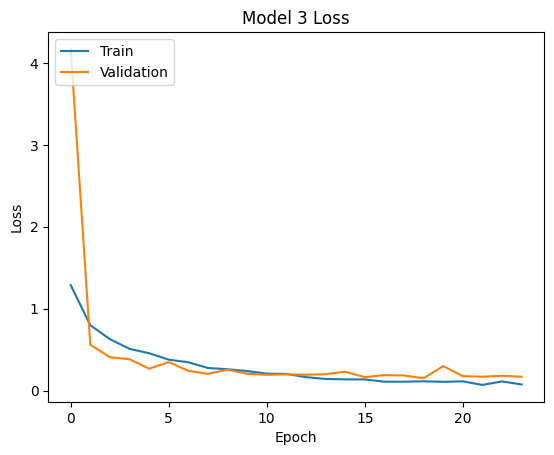

In [ ]:

#plotting train & validation loss
plt.plot(history3.history['loss'])
plt.plot(history3.history['val_loss'])
plt.title('Model 3 Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

In [ ]:
val_predictions3 = model3.predict(validation_ds)
val_predicted_classes3 = np.argmax(val_predictions3, axis=1)
val_true_classes3 = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in validation_ds])

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
print(classification_report(val_true_classes3, val_predicted_classes3, target_names=class_names))

95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step
              precision    recall  f1-score   support

      glioma       0.98      0.92      0.95      1013
  meningioma       0.91      0.97      0.94       779
     notumor       0.97      0.97      0.97       803
   pituitary       1.00      0.99      1.00       442

    accuracy                           0.96      3037
   macro avg       0.96      0.96      0.96      3037
weighted avg       0.96      0.96      0.96      3037



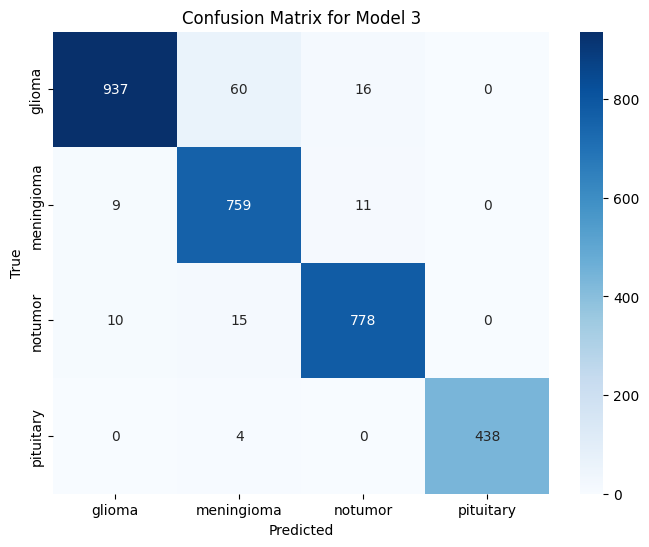

In [ ]:
cm3 = confusion_matrix(val_true_classes3, val_predicted_classes3) # Corrected variable name
plt.figure(figsize=(8, 6))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Model 3')
plt.show()

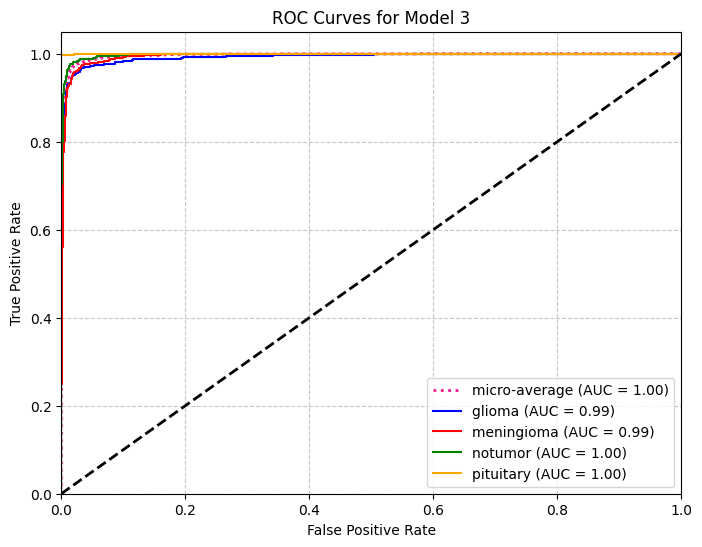

In [ ]:
# Model 3 ROC/AUC
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(class_names)

# True labels and prediction probabilities for Model 3 (using val_true_classes from previous cells)
y_true = val_true_classes3
y_pred_proba = val_predictions3

# Binarize true labels for one-vs-rest ROC
y_true_binarized = label_binarize(y_true, classes=range(NUM_CLASSES))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot all ROC curves
plt.figure(figsize=(8, 6))

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=2)

# Plot individual class ROC curves
colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Plot random chance line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Model 3')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Model 4: DenseNet-121 (Frozen) on Full Dataset with Class Weights, without Pituitary-Specific Augmentation

This model uses the DenseNet-121 architecture, pre-trained on ImageNet, as a frozen feature extractor, with only a custom classification head trained on top. It is trained on the full (naturally imbalanced) dataset with the same class weights used elsewhere (Pituitary weighted 2.0) to compensate for the minority class. Unlike Models 1–3, the pituitary-specific double-augmentation cycle is omitted here — a single, uniform augmentation policy is applied equally across all classes instead, to isolate the effect of the architecture change from the effect of the augmentation strategy.

Since DenseNet-121 expects 3-channel (RGB) input, the single-channel grayscale images are replicated across 3 channels during preprocessing.

In [ ]:

def load_and_preprocess_densenet(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=1, expand_animations=False) # Decode as 1 channel initially
    img = tf.image.resize(img, TARGET_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.concat([img, img, img], axis=-1) # Replicate channel for 3D input
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label


def make_dataset_for_densenet(paths, labels, shuffle=False, augment_data=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)
    ds = ds.map(load_and_preprocess_densenet, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


train_ds4 = make_dataset_for_densenet(X_train_paths_main, y_train_main, shuffle=True, augment_data=True)
validation_ds4 = make_dataset_for_densenet(X_val_paths_main, y_val_main, shuffle=False)
test_ds4 = make_dataset_for_densenet(X_test_paths_main, y_test_main, shuffle=False)

print(f"Training set size for Model 4: {len(X_train_paths_main)}")
print(f"Validation set size for Model 4: {len(X_val_paths_main)}")
print(f"Test set size for Model 4: {len(X_test_paths_main)}")

Training set size for Model 4: 12146
Validation set size for Model 4: 3037
Test set size for Model 4: 3796


In [ ]:
baseline_densenet = tf.keras.applications.DenseNet121(weights='imagenet', include_top=False, input_shape=(TARGET_SIZE[0], TARGET_SIZE[1], 3))

for layer in baseline_densenet.layers:
    layer.trainable = False

model4 = Sequential([
    baseline_densenet,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

model4.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 8, 8, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,932 (27.85 MB)

 Trainable params: 263,428 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
early_stop_model4 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
model4.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

start_time4 = time.time()
history4 = model4.fit(train_ds4, epochs=30, validation_data=validation_ds4, callbacks=[early_stop_model4], class_weight=class_weight_dict_standard)
end_time4 = time.time()
training_time4 = (end_time4 - start_time4) / 60  # Convert to minutes
print(f"Model 4 training time: {training_time4:.3f} minutes")

Epoch 1/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 124s 248ms/step - accuracy: 0.6601 - loss: 0.9601 - val_accuracy: 0.8146 - val_loss: 0.5227
Epoch 2/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 56s 147ms/step - accuracy: 0.8031 - loss: 0.5750 - val_accuracy: 0.8406 - val_loss: 0.4196
Epoch 3/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 55s 145ms/step - accuracy: 0.8380 - loss: 0.4765 - val_accuracy: 0.8624 - val_loss: 0.3647
Epoch 4/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 55s 145ms/step - accuracy: 0.8533 - loss: 0.4226 - val_accuracy: 0.8680 - val_loss: 0.3473
Epoch 5/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 56s 148ms/step - accuracy: 0.8656 - loss: 0.3877 - val_accuracy: 0.8798 - val_loss: 0.3156
Epoch 6/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 81s 145ms/step - accuracy: 0.8758 - loss: 0.3545 - val_accuracy: 0.8841 - val_loss: 0.3114
Epoch 7/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 56s 147ms/step - accuracy: 0.8820 - loss: 0.3375 - val_accuracy: 0.8933 - val_loss: 0.2943
Epoch 8/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 61s 161ms/step - accuracy: 0.8842 - loss: 

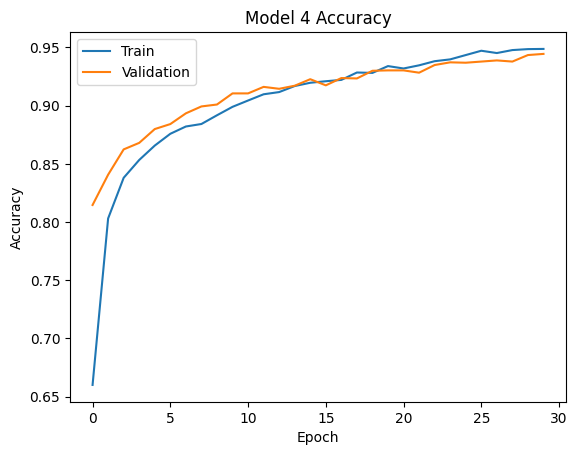

In [ ]:
# Plot training & validation accuracy values
plt.plot(history4.history['accuracy'])
plt.plot(history4.history['val_accuracy'])
plt.title('Model 4 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

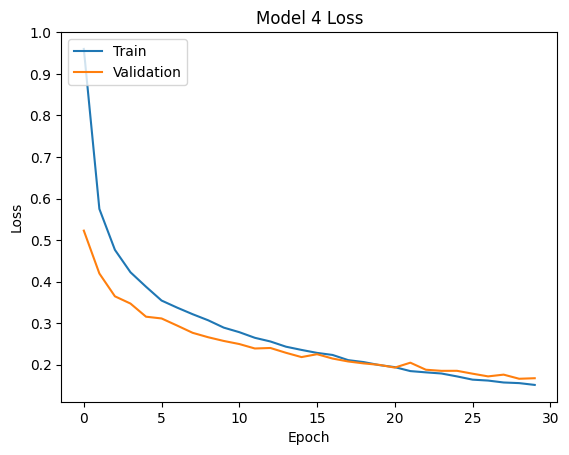

In [ ]:
# Plotting train & validation loss
plt.plot(history4.history['loss'])
plt.plot(history4.history['val_loss'])
plt.title('Model 4 Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
val_predictions4 = model4.predict(validation_ds4)
val_predicted_classes4 = np.argmax(val_predictions4, axis=1)
val_true_classes4 = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in validation_ds4])

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
print(classification_report(val_true_classes4, val_predicted_classes4, target_names=class_names))

95/95 ━━━━━━━━━━━━━━━━━━━━ 35s 244ms/step
              precision    recall  f1-score   support

      glioma       0.97      0.92      0.94      1013
  meningioma       0.90      0.92      0.91       779
     notumor       0.96      0.98      0.97       803
   pituitary       0.94      0.99      0.96       442

    accuracy                           0.94      3037
   macro avg       0.94      0.95      0.95      3037
weighted avg       0.94      0.94      0.94      3037



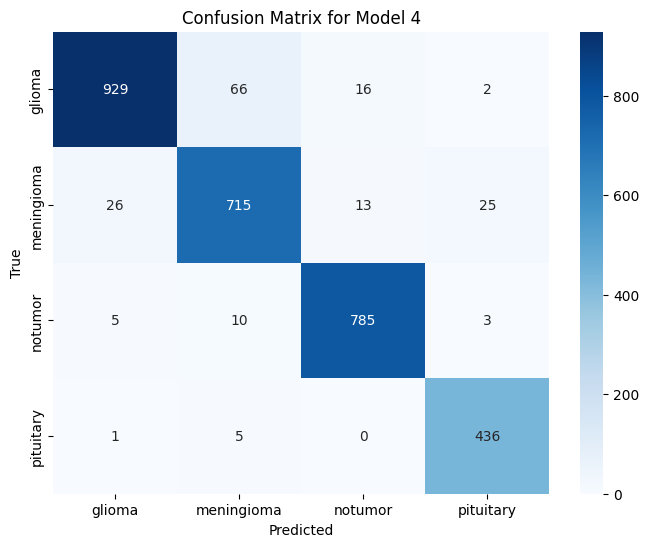

In [ ]:
cm4 = confusion_matrix(val_true_classes4, val_predicted_classes4)
plt.figure(figsize=(8, 6))
sns.heatmap(cm4, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Model 4')
plt.show()

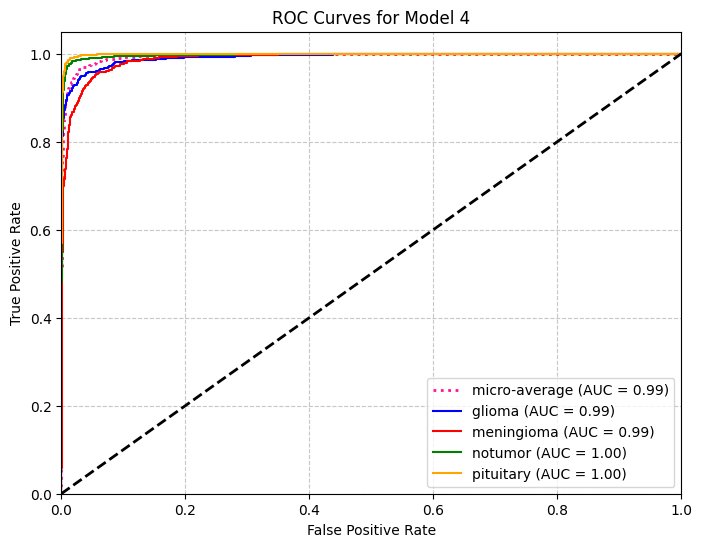

In [ ]:
# Model 4 ROC/AUC


class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(class_names)

# True labels and prediction probabilities for Model 4
y_true = val_true_classes4
y_pred_proba = val_predictions4

# Binarize true labels for one-vs-rest ROC
y_true_binarized = label_binarize(y_true, classes=range(NUM_CLASSES))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot all ROC curves
plt.figure(figsize=(8, 6))

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=2)

# Plot individual class ROC curves
colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Plot random chance line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Model 4')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### MODEL 5: TRAINING THE LAST 50 CONV LAYERS ON 0.00001 LEARNING RATE

In [ ]:
densenet_ft = DenseNet121(weights='imagenet', include_top=False, input_shape=(256,256,3))
for layer in densenet_ft.layers[:-50]:
    layer.trainable = False

model5 = Sequential([
    densenet_ft,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model5.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_model5 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

start_time5 = time.time()
history5 = model5.fit(
    train_ds4,
    validation_data=validation_ds4,
    epochs=20,
    callbacks=[early_stop_model5],
    class_weight=class_weight_dict_standard
)
end_time5 = time.time()
training_time5 = (end_time5 - start_time5) / 60  # Convert to minutes
print(f"Model 5 training time: {training_time5:.3f} minutes")

Epoch 1/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 133s 247ms/step - accuracy: 0.5264 - loss: 1.3003 - val_accuracy: 0.7965 - val_loss: 0.6217
Epoch 2/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 57s 150ms/step - accuracy: 0.7416 - loss: 0.7338 - val_accuracy: 0.8419 - val_loss: 0.4537
Epoch 3/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 56s 148ms/step - accuracy: 0.8069 - loss: 0.5621 - val_accuracy: 0.8607 - val_loss: 0.3806
Epoch 4/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 57s 149ms/step - accuracy: 0.8362 - loss: 0.4822 - val_accuracy: 0.8788 - val_loss: 0.3298
Epoch 5/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 57s 150ms/step - accuracy: 0.8565 - loss: 0.4188 - val_accuracy: 0.8907 - val_loss: 0.2955
Epoch 6/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 57s 149ms/step - accuracy: 0.8723 - loss: 0.3698 - val_accuracy: 0.8996 - val_loss: 0.2710
Epoch 7/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 57s 151ms/step - accuracy: 0.8855 - loss: 0.3370 - val_accuracy: 0.9068 - val_loss: 0.2488
Epoch 8/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 82s 150ms/step - accuracy: 0.8979 - loss: 

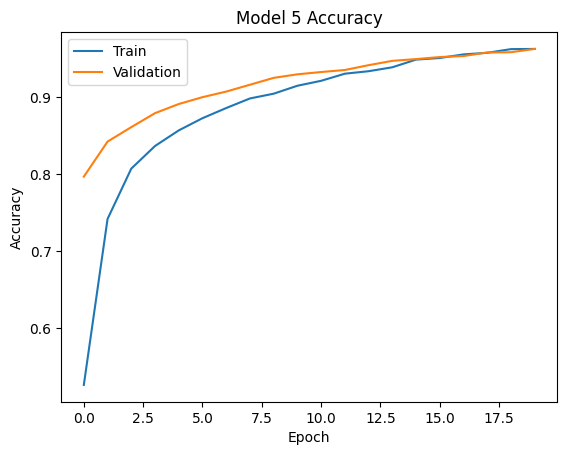

In [ ]:
# Plot training & validation accuracy values
plt.plot(history5.history['accuracy'])
plt.plot(history5.history['val_accuracy'])
plt.title('Model 5 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

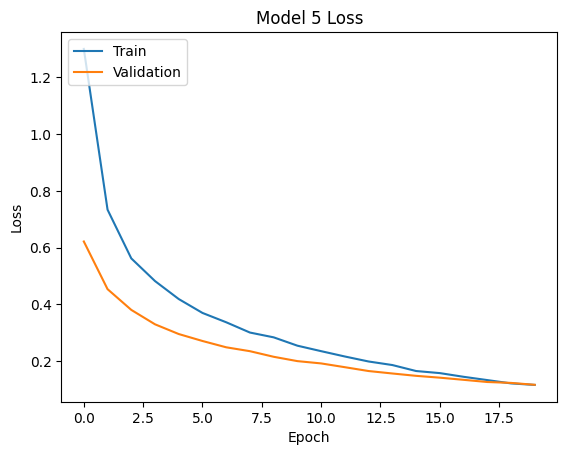

In [ ]:
# Plotting train & validation loss
plt.plot(history5.history['loss'])
plt.plot(history5.history['val_loss'])
plt.title('Model 5 Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
val_predictions5 = model5.predict(validation_ds4)
val_predicted_classes5 = np.argmax(val_predictions5, axis=1)
val_true_classes5 = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in validation_ds4])

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
print(classification_report(val_true_classes5, val_predicted_classes5, target_names=class_names))

95/95 ━━━━━━━━━━━━━━━━━━━━ 33s 229ms/step
              precision    recall  f1-score   support

      glioma       0.97      0.95      0.96      1013
  meningioma       0.95      0.94      0.94       779
     notumor       0.97      0.98      0.98       803
   pituitary       0.95      0.99      0.97       442

    accuracy                           0.96      3037
   macro avg       0.96      0.97      0.96      3037
weighted avg       0.96      0.96      0.96      3037



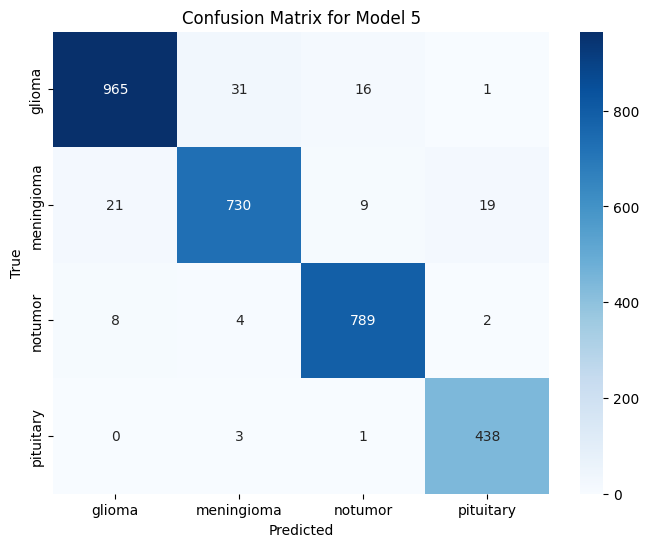

In [ ]:
cm5 = confusion_matrix(val_true_classes5, val_predicted_classes5)
plt.figure(figsize=(8, 6))
sns.heatmap(cm5, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Model 5')
plt.show()

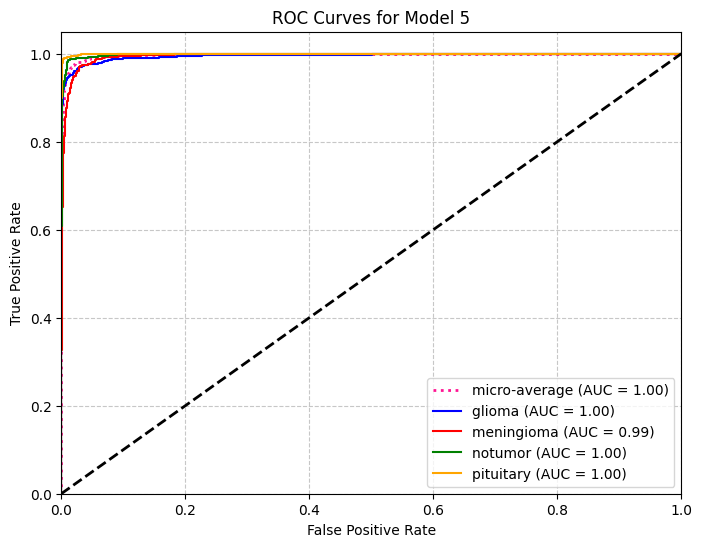

In [ ]:
# Model 5 ROC/AUC

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(class_names)

# True labels and prediction probabilities for Model 5
y_true = val_true_classes5
y_pred_proba = val_predictions5

# Binarize true labels for one-vs-rest ROC
y_true_binarized = label_binarize(y_true, classes=range(NUM_CLASSES))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot all ROC curves
plt.figure(figsize=(8, 6))

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=2)

# Plot individual class ROC curves
colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Plot random chance line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Model 5')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Model 6: Custom CNN at 512x512 Resolution

This model tests whether a higher input resolution of 512x512 improves the performance of a from-scratch CNN compared to the earlier 256x256 models. Given the increased resolution, the batch size is reduced to prevent out-of-memory errors. This resolution was chosen because 512x512 was the most common image resolution found in the dataset.

In [ ]:
TARGET_SIZE_512 = (512, 512)
BATCH_SIZE_512 = 8

def load_and_preprocess_512(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=1, expand_animations=False)
    img = tf.image.resize(img, TARGET_SIZE_512)
    img = tf.cast(img, tf.float32) / 255.0
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

def make_dataset_512(paths, labels, shuffle=False, augment_data=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)
    ds = ds.map(load_and_preprocess_512, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
        ds = ds.map(augment_pituitary, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE_512).prefetch(AUTOTUNE)
    return ds

train_ds6 = make_dataset_512(X_train_paths_main, y_train_main, shuffle=True, augment_data=True)
validation_ds6 = make_dataset_512(X_val_paths_main, y_val_main, shuffle=False)
test_ds6 = make_dataset_512(X_test_paths_main, y_test_main, shuffle=False)

In [ ]:
model6 = Sequential()

model6.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(TARGET_SIZE_512[0], TARGET_SIZE_512[1], 1)))
model6.add(BatchNormalization())
model6.add(MaxPooling2D((2,2)))

model6.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model6.add(BatchNormalization())
model6.add(MaxPooling2D((2,2)))

model6.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model6.add(BatchNormalization())
model6.add(MaxPooling2D((2,2)))

model6.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model6.add(BatchNormalization())
model6.add(MaxPooling2D((2,2)))

model6.add(Conv2D(512, (3,3), activation='relu', padding='same'))
model6.add(BatchNormalization())
model6.add(MaxPooling2D((2,2)))

model6.add(GlobalAveragePooling2D())
model6.add(Dense(256, activation='relu'))
model6.add(Dropout(0.5))
model6.add(Dense(NUM_CLASSES, activation='softmax'))

model6.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 512, 512, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 512, 512, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 256, 256, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 64, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 32, 32, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,704,324 (6.50 MB)

 Trainable params: 1,702,340 (6.49 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

early_stop_model6 = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr_model6 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

model6.compile(
    optimizer=Adam(learning_rate=0.00005, clipnorm=1.0),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time6 = time.time()
history6 = model6.fit(
    train_ds6,
    epochs=30,
    validation_data=validation_ds6,
    class_weight=class_weight_dict_standard,
    callbacks=[early_stop_model6, reduce_lr_model6]
)
end_time6 = time.time()
training_time6 = (end_time6 - start_time6) / 60
print(f"Model 6 training time: {training_time6:.3f} minutes")

Epoch 1/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 198s 117ms/step - accuracy: 0.6061 - loss: 1.0616 - val_accuracy: 0.7856 - val_loss: 0.5892 - learning_rate: 5.0000e-05
Epoch 2/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 162s 107ms/step - accuracy: 0.7236 - loss: 0.7954 - val_accuracy: 0.7978 - val_loss: 0.5020 - learning_rate: 5.0000e-05
Epoch 3/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 160s 105ms/step - accuracy: 0.7704 - loss: 0.6702 - val_accuracy: 0.8324 - val_loss: 0.4886 - learning_rate: 5.0000e-05
Epoch 4/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 160s 105ms/step - accuracy: 0.8016 - loss: 0.5713 - val_accuracy: 0.8410 - val_loss: 0.4432 - learning_rate: 5.0000e-05
Epoch 5/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 159s 105ms/step - accuracy: 0.8274 - loss: 0.4929 - val_accuracy: 0.7363 - val_loss: 0.6571 - learning_rate: 5.0000e-05
Epoch 6/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 160s 105ms/step - accuracy: 0.8437 - loss: 0.4608 - val_accuracy: 0.8472 - val_loss: 0.3900 - learning_rate: 5.0000e-05
Epoch 7/30
1519/1519 ━━━━━━━

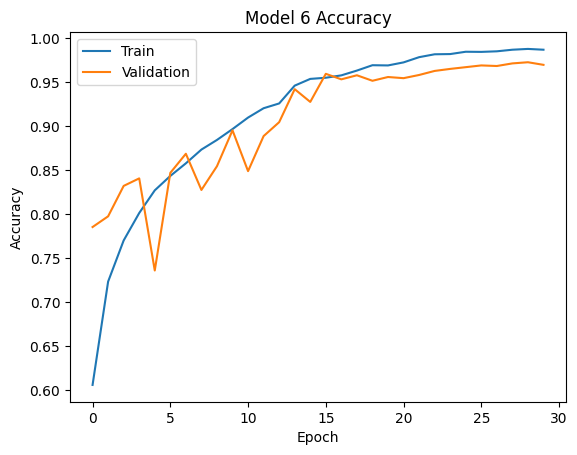

In [ ]:
# Plot training & validation accuracy values
plt.plot(history6.history['accuracy'])
plt.plot(history6.history['val_accuracy'])
plt.title('Model 6 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

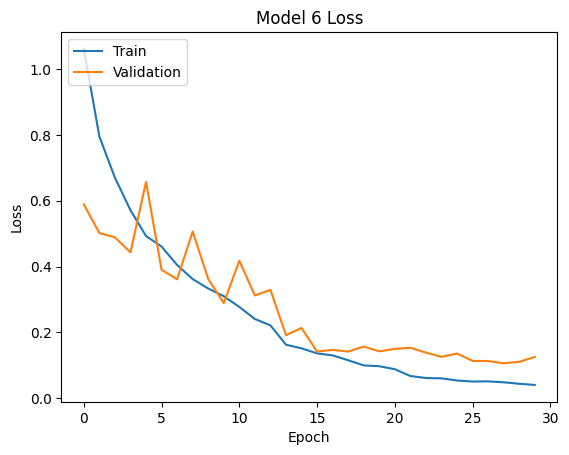

In [ ]:
# Plotting train & validation loss
plt.plot(history6.history['loss'])
plt.plot(history6.history['val_loss'])
plt.title('Model 6 Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
val_predictions6 = model6.predict(validation_ds6)
val_predicted_classes6 = np.argmax(val_predictions6, axis=1)
val_true_classes6 = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in validation_ds6])

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
print(classification_report(val_true_classes6, val_predicted_classes6, target_names=class_names))

380/380 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step
              precision    recall  f1-score   support

      glioma       0.98      0.97      0.97      1013
  meningioma       0.97      0.96      0.96       779
     notumor       0.96      0.98      0.97       803
   pituitary       0.98      0.99      0.99       442

    accuracy                           0.97      3037
   macro avg       0.97      0.97      0.97      3037
weighted avg       0.97      0.97      0.97      3037



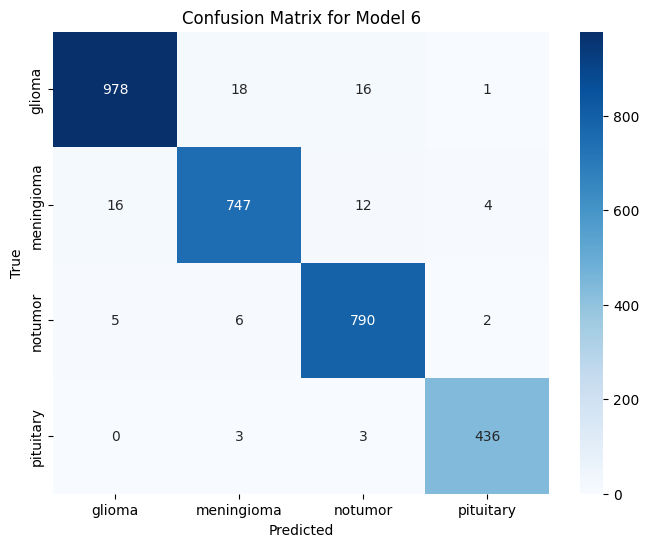

In [ ]:
cm6 = confusion_matrix(val_true_classes6, val_predicted_classes6)
plt.figure(figsize=(8, 6))
sns.heatmap(cm6, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Model 6')
plt.show()

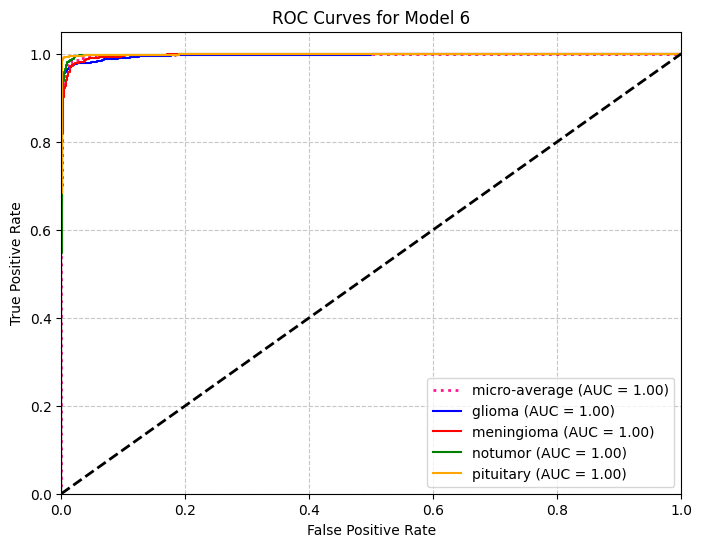

In [ ]:
# Model 6 ROC/AUC


class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(class_names)

# True labels and prediction probabilities for Model 6
y_true = val_true_classes6
y_pred_proba = val_predictions6

# Binarize true labels for one-vs-rest ROC
y_true_binarized = label_binarize(y_true, classes=range(NUM_CLASSES))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot all ROC curves
plt.figure(figsize=(8, 6))

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=2)

# Plot individual class ROC curves
colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Plot random chance line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Model 6')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Model 7: EfficientNetB0 Transfer Learning at 512x512

This model tests whether increasing the input resolution to 512x512 also benefits transfer learning performance, serving as a counterpart to Model 7 (same resolution, from-scratch CNN) and Models 5/6 (DenseNet121 at 256x256). It reuses the same training and validation path splits as Model 7, but employs EfficientNet-specific preprocessing (3-channel conversion and `preprocess_input`) which is necessary for its pre-trained weights, unlike Model 7's single-channel, manual /255 normalization.

In [ ]:
# Reusing TARGET_SIZE_512 and BATCH_SIZE_512 from Model 6's section
# TARGET_SIZE_512 = (512, 512)
# BATCH_SIZE_512 = 8

def load_and_preprocess_efficientnet_512(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=1, expand_animations=False) # Decode as 1 channel
    img = tf.image.grayscale_to_rgb(img) # Convert to 3 channels for EfficientNet
    img = tf.image.resize(img, TARGET_SIZE_512)
    img = preprocess_input(img) # EfficientNet specific preprocessing
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

def make_dataset_efficientnet_512(paths, labels, shuffle=False, augment_data=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)
    ds = ds.map(load_and_preprocess_efficientnet_512, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE_512).prefetch(AUTOTUNE)
    return ds

# Build datasets using the same train/val paths as Model 6
train_ds7 = make_dataset_efficientnet_512(X_train_paths_main, y_train_main, shuffle=True, augment_data=True)
validation_ds7 = make_dataset_efficientnet_512(X_val_paths_main, y_val_main, shuffle=False)
test_ds7 = make_dataset_efficientnet_512(X_test_paths_main, y_test_main, shuffle=False)

print(f"Training set size for Model 7: {len(X_train_paths_main)}")
print(f"Validation set size for Model 7: {len(X_val_paths_main)}")

Training set size for Model 7: 12146
Validation set size for Model 7: 3037


In [ ]:
# Load EfficientNetB0 pre-trained on ImageNet, excluding the top (classification) layer
baseline_efficientnet = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(TARGET_SIZE_512[0], TARGET_SIZE_512[1], 3))

# Freeze the layers of the pre-trained model
for layer in baseline_efficientnet.layers:
    layer.trainable = False

# Create Model 7
model7 = Sequential([
    baseline_efficientnet,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model7.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 16, 16, 1280)   │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
early_stop_model7 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model7.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time7 = time.time()
history7 = model7.fit(
    train_ds7,
    epochs=30,
    validation_data=validation_ds7,
    class_weight=class_weight_dict_standard,
    callbacks=[early_stop_model7]
)
end_time7 = time.time()

training_time7 = (end_time7 - start_time7) / 60 # Convert to minutes
print(f"Model 7 training time: {training_time7:.3f} minutes")

Epoch 1/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 157s 84ms/step - accuracy: 0.7886 - loss: 0.6260 - val_accuracy: 0.8722 - val_loss: 0.3455
Epoch 2/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 94s 62ms/step - accuracy: 0.8662 - loss: 0.3857 - val_accuracy: 0.8923 - val_loss: 0.2776
Epoch 3/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 89s 58ms/step - accuracy: 0.8833 - loss: 0.3311 - val_accuracy: 0.8923 - val_loss: 0.2646
Epoch 4/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 89s 58ms/step - accuracy: 0.8995 - loss: 0.2885 - val_accuracy: 0.9052 - val_loss: 0.2410
Epoch 5/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 93s 61ms/step - accuracy: 0.9052 - loss: 0.2650 - val_accuracy: 0.9164 - val_loss: 0.2124
Epoch 6/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 138s 59ms/step - accuracy: 0.9134 - loss: 0.2399 - val_accuracy: 0.9177 - val_loss: 0.2052
Epoch 7/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 89s 58ms/step - accuracy: 0.9194 - loss: 0.2275 - val_accuracy: 0.9285 - val_loss: 0.1850
Epoch 8/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 89s 58ms/step - accuracy: 0.9275

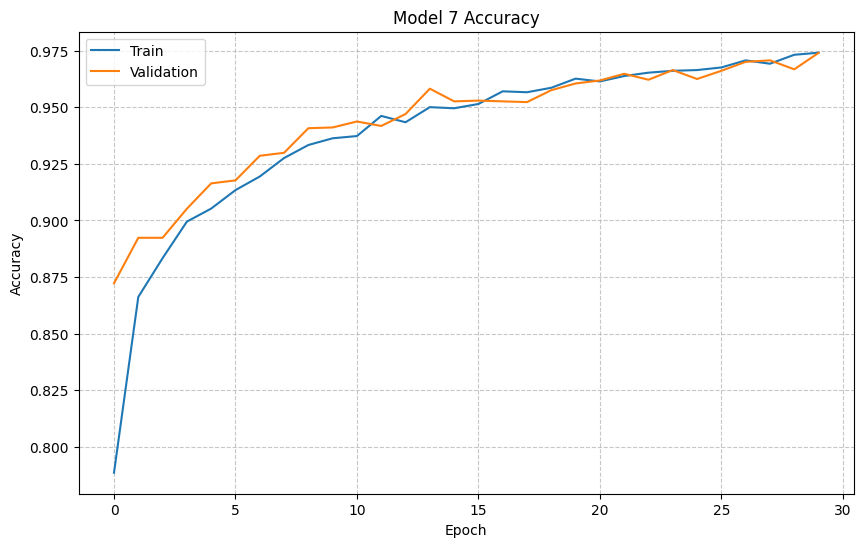

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history7.history['accuracy'])
plt.plot(history7.history['val_accuracy'])
plt.title('Model 7 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

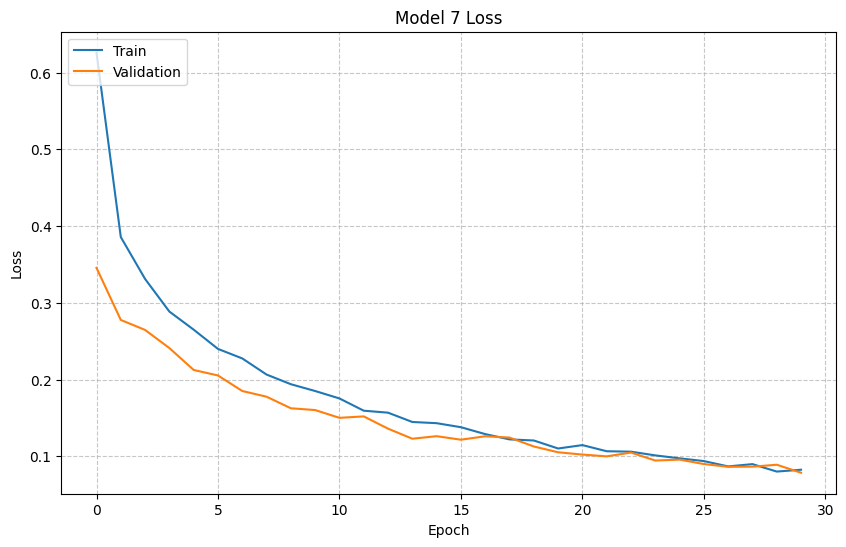

In [ ]:
# Plotting train & validation loss
plt.figure(figsize=(10, 6))
plt.plot(history7.history['loss'])
plt.plot(history7.history['val_loss'])
plt.title('Model 7 Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
val_predictions7 = model7.predict(validation_ds7)
val_predicted_classes7 = np.argmax(val_predictions7, axis=1)
val_true_classes7 = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in validation_ds7])

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
print(classification_report(val_true_classes7, val_predicted_classes7, target_names=class_names))

380/380 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step
              precision    recall  f1-score   support

      glioma       0.98      0.96      0.97      1013
  meningioma       0.94      0.97      0.96       779
     notumor       0.99      0.99      0.99       803
   pituitary       0.99      0.99      0.99       442

    accuracy                           0.97      3037
   macro avg       0.97      0.98      0.98      3037
weighted avg       0.97      0.97      0.97      3037



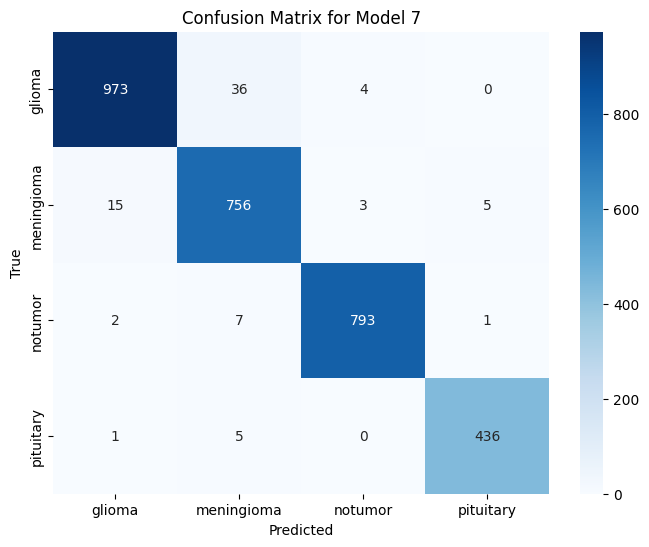

In [ ]:
cm7 = confusion_matrix(val_true_classes7, val_predicted_classes7)
plt.figure(figsize=(8, 6))
sns.heatmap(cm7, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Model 7')
plt.show()

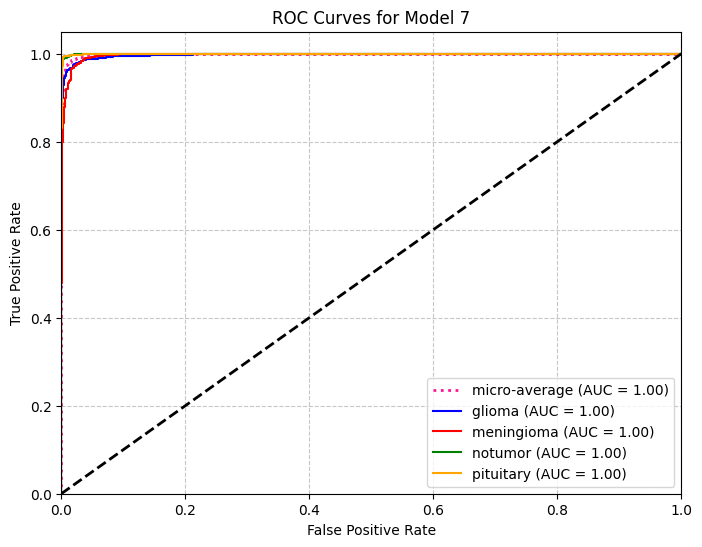

In [ ]:
# Model 7 ROC/AUC

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(class_names)

# True labels and prediction probabilities for Model 7
y_true = val_true_classes7
y_pred_proba = val_predictions7

# Binarize true labels for one-vs-rest ROC
y_true_binarized = label_binarize(y_true, classes=range(NUM_CLASSES))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot all ROC curves
plt.figure(figsize=(8, 6))

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=2)

# Plot individual class ROC curves
colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Plot random chance line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Model 7')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Final Model Comparison (Models 1-7)

In [ ]:
# Define a list of dictionaries for each model's data
models_data = [
    {
        'Model Name': 'Model 1',
        'val_true_classes': val_true_classes1,
        'val_predicted_classes': val_predicted_classes1,
        'val_predictions': val_predictions1,
        'training_time_min': training_time1, # Now in minutes
        'history': history1
    },
    {
        'Model Name': 'Model 2',
        'val_true_classes': val_true_classes2,
        'val_predicted_classes': val_predicted_classes2,
        'val_predictions': val_predictions2,
        'training_time_min': training_time2, # Now in minutes
        'history': history2
    },
    {
        'Model Name': 'Model 3',
        'val_true_classes': val_true_classes3,
        'val_predicted_classes': val_predicted_classes3,
        'val_predictions': val_predictions3,
        'training_time_min': training_time3, # Now in minutes
        'history': history3
    },
    {
        'Model Name': 'Model 4',
        'val_true_classes': val_true_classes4,
        'val_predicted_classes': val_predicted_classes4,
        'val_predictions': val_predictions4,
        'training_time_min': training_time4, # Now in minutes
        'history': history4
    },
    {
        'Model Name': 'Model 5',
        'val_true_classes': val_true_classes5,
        'val_predicted_classes': val_predicted_classes5,
        'val_predictions': val_predictions5,
        'training_time_min': training_time5, # Now in minutes
        'history': history5
    },
    {
        'Model Name': 'Model 6',
        'val_true_classes': val_true_classes6,
        'val_predicted_classes': val_predicted_classes6,
        'val_predictions': val_predictions6,
        'training_time_min': training_time6, # Now in minutes
        'history': history6
    },
    {
        'Model Name': 'Model 7',
        'val_true_classes': val_true_classes7,
        'val_predicted_classes': val_predicted_classes7,
        'val_predictions': val_predictions7,
        'training_time_min': training_time7, # Now in minutes
        'history': history7
    }
]

# Prepare lists to store results
results = []

for model in models_data:
    model_name = model['Model Name']
    y_true = model['val_true_classes']
    y_pred = model['val_predicted_classes']
    y_pred_proba = model['val_predictions']
    training_time_min_val = model['training_time_min'] # Retrieve in minutes
    model_history = model['history']

    # Calculate metrics
    val_accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    macro_auc = roc_auc_score(y_true, y_pred_proba, average='macro', multi_class='ovr')
    val_loss = min(model_history.history['val_loss']) # Get the minimum validation loss

    results.append({
        'Model': model_name,
        'Validation Accuracy': val_accuracy,
        'Macro F1-Score': macro_f1,
        'Macro AUC': macro_auc,
        'Validation Loss': round(val_loss, 3), # Add validation loss, rounded to 3 decimal places
        'Training Time (min)': round(training_time_min_val, 3) # Use the value directly
    })

# Create DataFrame
comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.set_index('Model')
# Display the DataFrame
display(comparison_df)

,Validation Accuracy,Macro F1-Score,Macro AUC,Validation Loss,Training Time (min)
Model,,,,,
Model 1,0.951268,0.955943,0.994634,0.160,16.531
Model 2,0.962134,0.966033,0.995807,0.134,14.988
Model 3,0.958841,0.963411,0.996257,0.151,18.182
Model 4,0.943365,0.945115,0.994254,0.166,33.691
Model 5,0.962134,0.962962,0.996964,0.117,21.874
Model 6,0.971683,0.973098,0.997656,0.106,81.421
Model 7,0.973987,0.975507,0.998558,0.078,53.798


## Combined ROC Comparison Across Models

/tmp/ipykernel_495/1222896297.py:33: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k--" (-> linestyle='--'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', lw=2, color='gray', linestyle='--',
/tmp/ipykernel_495/1222896297.py:33: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', lw=2, color='gray', linestyle='--',


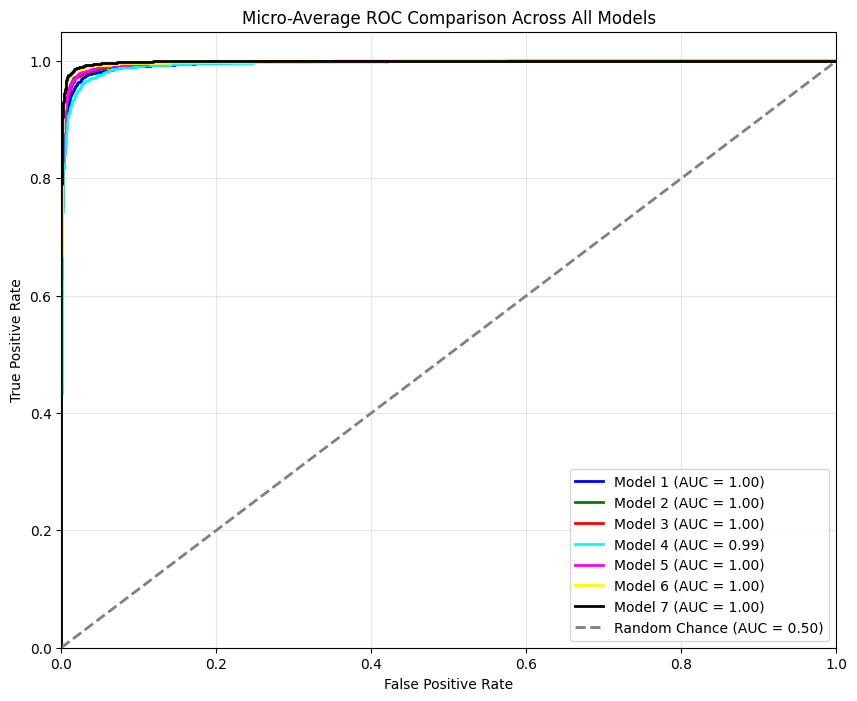

In [ ]:
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(class_names)

# List of (model_name, val_true_classes, val_predictions) tuples for specified models
model_performance_data = [
    ('Model 1', val_true_classes1, val_predictions1),
    ('Model 2', val_true_classes2, val_predictions2),
    ('Model 3', val_true_classes3, val_predictions3),
    ('Model 4', val_true_classes4, val_predictions4),
    ('Model 5', val_true_classes5, val_predictions5),
    ('Model 6', val_true_classes6, val_predictions6),
    ('Model 7', val_true_classes7, val_predictions7)
]

plt.figure(figsize=(10, 8))

colors = ['blue', 'green', 'red', 'cyan', 'magenta', 'yellow', 'black'] # Different colors for each model

for idx, (model_name, y_true, y_pred_proba) in enumerate(model_performance_data):
    # Binarize true labels for one-vs-rest ROC
    y_true_binarized = label_binarize(y_true, classes=range(NUM_CLASSES))

    # Compute micro-average ROC curve and AUC
    fpr_micro, tpr_micro, _ = roc_curve(y_true_binarized.ravel(), y_pred_proba.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro)

    # Plot the micro-average ROC curve for the current model
    plt.plot(fpr_micro, tpr_micro,
             label=f'{model_name} (AUC = {roc_auc_micro:.2f})',
             color=colors[idx], linewidth=2)

# Plot random chance line
plt.plot([0, 1], [0, 1], 'k--', lw=2, color='gray', linestyle='--',
         label='Random Chance (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Micro-Average ROC Comparison Across All Models')
plt.legend(loc='lower right', fontsize='medium') # Set font size for readability
plt.grid(True, alpha=0.3) # Add a light grid
plt.show()

### Weighted Multi-Criteria Ranking

In [ ]:
# Stability metric: how much val_accuracy jumps epoch-to-epoch (lower = more stable)
# Using std of epoch-to-epoch differences, not raw std, so a normally-improving
# model isn't penalized just for trending upward over training.
def compute_stability(history):
    val_acc = history.history['val_accuracy']
    diffs = np.diff(val_acc)
    return np.std(diffs)

comparison_df['Stability_Score'] = [
    compute_stability(h) for h in
    [history1, history2, history3, history4, history5, history6, history7]
]

# 1. Create rank columns for each metric
comparison_df['Accuracy_Rank'] = comparison_df['Validation Accuracy'].rank(ascending=False)
comparison_df['F1_Rank'] = comparison_df['Macro F1-Score'].rank(ascending=False)
comparison_df['AUC_Rank'] = comparison_df['Macro AUC'].rank(ascending=False)
comparison_df['Loss_Rank'] = comparison_df['Validation Loss'].rank(ascending=True)
comparison_df['Time_Rank'] = comparison_df['Training Time (min)'].rank(ascending=True)
comparison_df['Stability_Rank'] = comparison_df['Stability_Score'].rank(ascending=True)  # lower std = better rank

# 2. Weighted average rank
WEIGHTS = {
    'Accuracy_Rank': 1.0,
    'F1_Rank': 1.0,
    'AUC_Rank': 1.0,
    'Loss_Rank': 0.5,
    'Stability_Rank': 0.4,   # meaningful weight — instability is a real reliability concern
    'Time_Rank': 0.15
}
TOTAL_WEIGHT = sum(WEIGHTS.values())

comparison_df['Weighted_Avg_Rank'] = sum(
    comparison_df[col] * w for col, w in WEIGHTS.items()
) / TOTAL_WEIGHT

# 3. Sort by weighted average rank ascending (lower = better overall)
comparison_df = comparison_df.sort_values(by='Weighted_Avg_Rank', ascending=True)

print("\n--- Ranked Model Comparison ---")
display(comparison_df)

print(f"\nThe #1 model based on Weighted Average Rank is: {comparison_df.index[0]}")


--- Ranked Model Comparison ---


,Validation Accuracy,Macro F1-Score,Macro AUC,Validation Loss,Training Time (min),Stability_Score,Accuracy_Rank,F1_Rank,AUC_Rank,Loss_Rank,Time_Rank,Stability_Rank,Weighted_Avg_Rank
Model,,,,,,,,,,,,,
Model 7,0.973987,0.975507,0.998558,0.078,53.798,0.005745,1.0,1.0,1.0,1.0,6.0,1.0,1.185185
Model 6,0.971683,0.973098,0.997656,0.106,81.421,0.034692,2.0,2.0,2.0,2.0,7.0,4.0,2.382716
Model 5,0.962134,0.962962,0.996964,0.117,21.874,0.009980,3.5,5.0,3.0,3.0,4.0,3.0,3.654321
Model 2,0.962134,0.966033,0.995807,0.134,14.988,0.107513,3.5,3.0,5.0,4.0,1.0,7.0,4.061728
Model 3,0.958841,0.963411,0.996257,0.151,18.182,0.076920,5.0,4.0,4.0,5.0,3.0,5.0,4.432099
Model 1,0.951268,0.955943,0.994634,0.160,16.531,0.095865,6.0,6.0,6.0,6.0,2.0,6.0,5.851852
Model 4,0.943365,0.945115,0.994254,0.166,33.691,0.006548,7.0,7.0,7.0,7.0,5.0,2.0,6.432099



The #1 model based on Weighted Average Rank is: Model 7


## Final Test Set Evaluation — Best Model (Test Set Touched Once)

In [ ]:
# 1. Identify the best model from the comparison_df
best_model_name = comparison_df.index[0]
print(f"Selected Best Model (based on Validation Macro F1-Score): {best_model_name}\n")

# 2. Define the mapping for models and test datasets
model_and_dataset_map = {
    "Model 1": (model1, test_ds),
    "Model 2": (model2, test_ds),
    "Model 3": (model3, test_ds),
    "Model 4": (model4, test_ds4),
    "Model 5": (model5, test_ds4),
    "Model 6": (model6, test_ds6),
    "Model 7": (model7, test_ds7),
}

# Retrieve the best model object and its corresponding test dataset
best_model, best_test_dataset = model_and_dataset_map[best_model_name]

# 3. Run prediction on the test set for the winning model
print(f"Evaluating {best_model_name} on the Test Set...\n")
test_predictions = best_model.predict(best_test_dataset)
test_predicted_classes = np.argmax(test_predictions, axis=1)

# Get true classes from the test dataset
test_true_classes = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in best_test_dataset])

Selected Best Model (based on Validation Macro F1-Score): Model 7

Evaluating Model 7 on the Test Set...

475/475 ━━━━━━━━━━━━━━━━━━━━ 33s 69ms/step


In [ ]:
print("Classification Report (Test Set):")
print(classification_report(test_true_classes, test_predicted_classes, target_names=class_names))

Classification Report (Test Set):
              precision    recall  f1-score   support

      glioma       0.98      0.97      0.97      1266
  meningioma       0.95      0.97      0.96       975
     notumor       0.99      0.99      0.99      1003
   pituitary       0.99      0.98      0.99       552

    accuracy                           0.98      3796
   macro avg       0.98      0.98      0.98      3796
weighted avg       0.98      0.98      0.98      3796



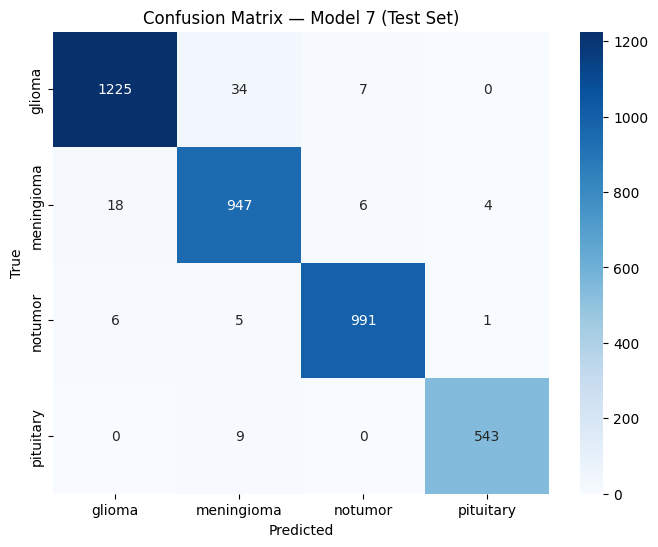

In [ ]:
cm = confusion_matrix(test_true_classes, test_predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix — {best_model_name} (Test Set)')
plt.show()

/tmp/ipykernel_495/1207613199.py:24: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k--" (-> linestyle='--'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', lw=2, color='gray', linestyle='--',
/tmp/ipykernel_495/1207613199.py:24: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', lw=2, color='gray', linestyle='--',


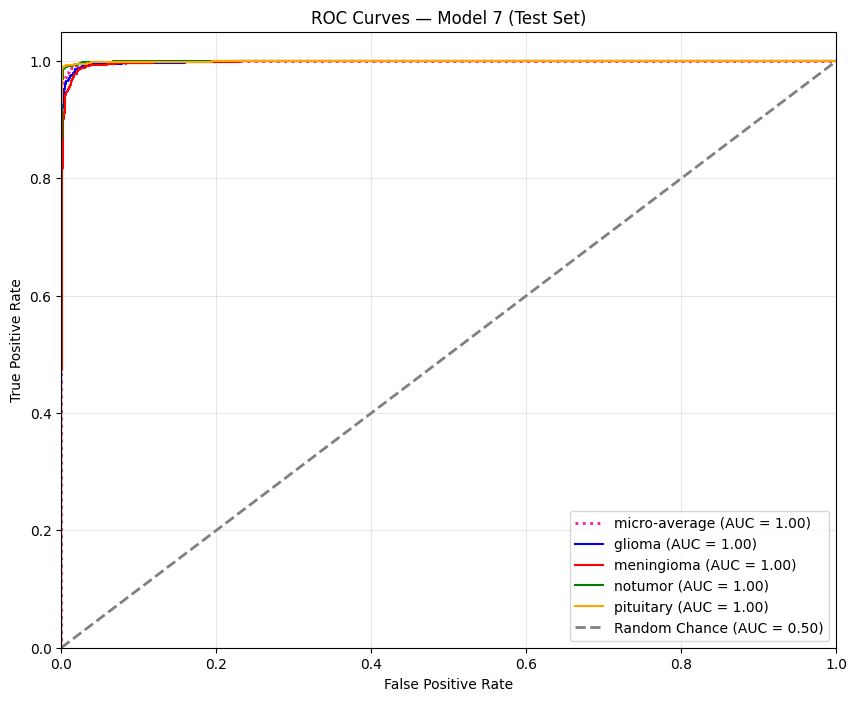

In [ ]:
y_true_binarized_test = label_binarize(test_true_classes, classes=range(NUM_CLASSES))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized_test[:, i], test_predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized_test.ravel(), test_predictions.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(10, 8))
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=2)

colors_roc = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(NUM_CLASSES), colors_roc):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, color='gray', linestyle='--',
         label='Random Chance (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curves — {best_model_name} (Test Set)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

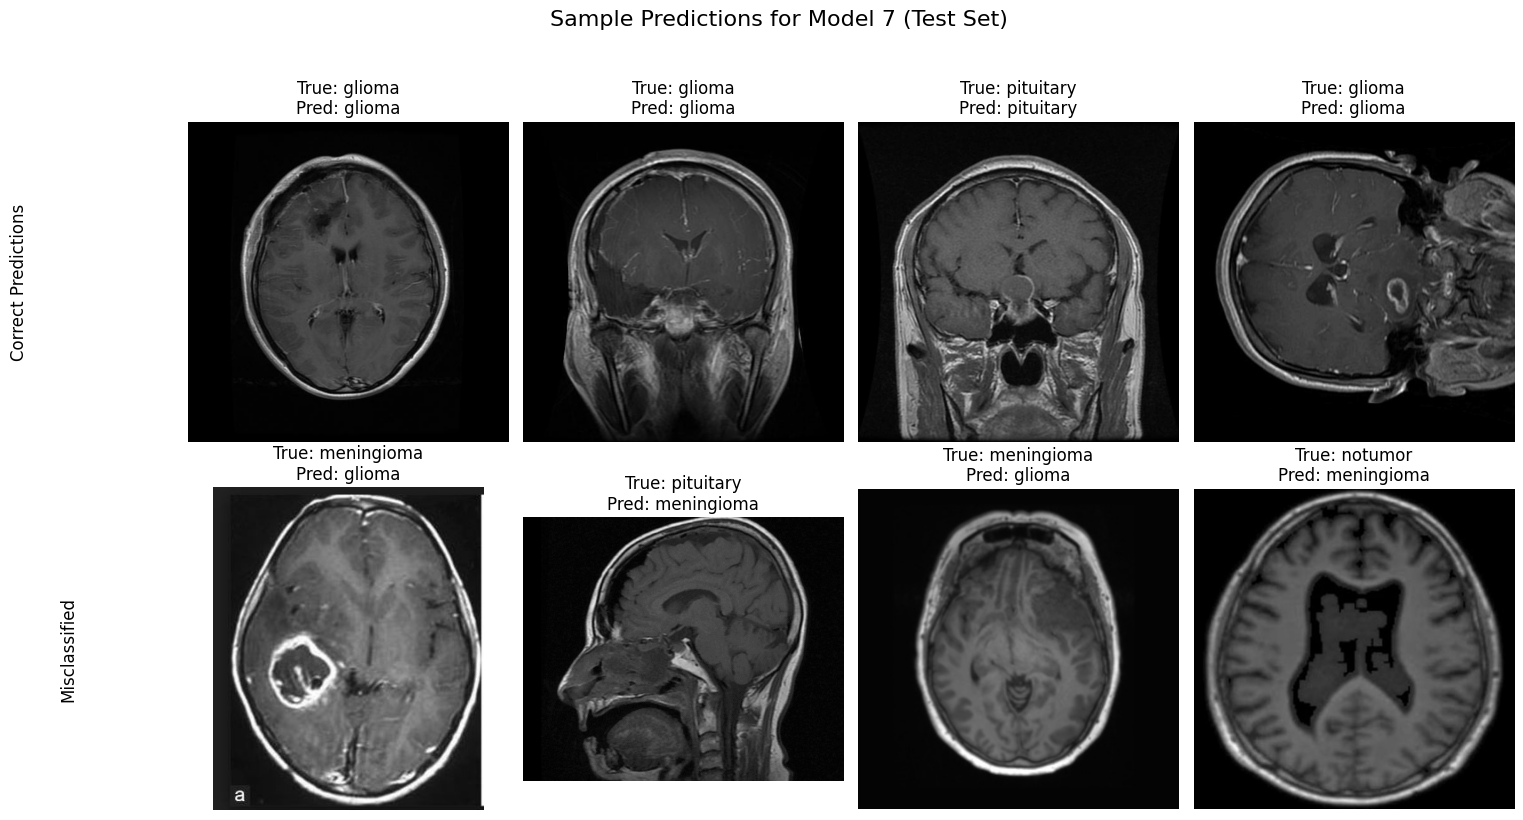

In [ ]:
test_paths = X_test_paths_main

test_results_for_display = []
for i in range(len(test_paths)):
    test_results_for_display.append({
        'path': test_paths[i],
        'true_label_idx': test_true_classes[i],
        'predicted_label_idx': test_predicted_classes[i]
    })

correct_examples = []
misclassified_examples = []

for item in test_results_for_display:
    if item['true_label_idx'] == item['predicted_label_idx']:
        correct_examples.append(item)
    else:
        misclassified_examples.append(item)

num_to_display = 4
selected_correct = correct_examples[:num_to_display]
selected_misclassified = misclassified_examples[:num_to_display]

fig, axes = plt.subplots(2, num_to_display, figsize=(15, 8))
fig.suptitle(f"Sample Predictions for {best_model_name} (Test Set)", fontsize=16, y=1.02)

for i, ax in enumerate(axes[0]):
    if i < len(selected_correct):
        item = selected_correct[i]
        try:
            img = Image.open(item['path'])
            ax.imshow(img, cmap='gray')
            ax.set_title(f"True: {class_names[item['true_label_idx']]}\nPred: {class_names[item['predicted_label_idx']]}")
            ax.axis('off')
        except Exception as e:
            ax.set_title(f"Load Error: {e}")
            ax.axis('off')
    else:
        ax.axis('off')

for i, ax in enumerate(axes[1]):
    if i < len(selected_misclassified):
        item = selected_misclassified[i]
        try:
            img = Image.open(item['path'])
            ax.imshow(img, cmap='gray')
            ax.set_title(f"True: {class_names[item['true_label_idx']]}\nPred: {class_names[item['predicted_label_idx']]}")
            ax.axis('off')
        except Exception as e:
            ax.set_title(f"Load Error: {e}")
            ax.axis('off')
    else:
        ax.axis('off')

axes[0, 0].text(-0.5, 0.5, "Correct Predictions", rotation=90, va='center', ha='right', transform=axes[0, 0].transAxes, fontsize=12)
axes[1, 0].text(-0.5, 0.5, "Misclassified", rotation=90, va='center', ha='right', transform=axes[1, 0].transAxes, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## Model 8: Balanced Dataset (undersampling) without Class Weights

For this model, we will address the class imbalance by undersampling the larger classes to match the number of images in the smallest class (pituitary). This creates a balanced dataset, and therefore, we will train the model without explicit class weights. The double augmentation for pituitary images will also be removed for this model, by using a new `make_dataset` function specific to Model 4.

In [ ]:
def augment_model8(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    return image, label

In [ ]:
# New make_dataset function for Model 8 without pituitary augmentation
def make_dataset_for_model8(paths, labels, shuffle=False, augment_data=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment_model8, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

In [ ]:
print(f"Number of pituitary images: {len(classes_data['pituitary'])}")
print(f"Total images in balanced dataset: {len(balanced_paths)}")
print(f"Distribution of classes in balanced dataset: {Counter(balanced_labels)}")


train_ds8 = make_dataset_for_model8(X_train_paths_balanced, y_train_balanced, shuffle=True, augment_data=True)
validation_ds8 = make_dataset_for_model8(X_val_paths_balanced, y_val_balanced, shuffle=False)
test_ds8 = make_dataset_for_model8(X_test_paths_balanced, y_test_balanced, shuffle=False)

print(f"Balanced Training set size: {len(X_train_paths_balanced)}")
print(f"Balanced Validation set size: {len(X_val_paths_balanced)}")
print(f"Balanced Test set size: {len(X_test_paths_balanced)}")

Number of pituitary images: 2761
Total images in balanced dataset: 11044
Distribution of classes in balanced dataset: Counter({np.int64(0): 2761, np.int64(1): 2761, np.int64(2): 2761, np.int64(3): 2761})
Balanced Training set size: 7068
Balanced Validation set size: 1767
Balanced Test set size: 2209


In [ ]:
model8 = Sequential()

model8.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(256,256,1)))
model8.add(BatchNormalization())
model8.add(MaxPooling2D((2,2)))

model8.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model8.add(BatchNormalization())
model8.add(MaxPooling2D((2,2)))

model8.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model8.add(BatchNormalization())
model8.add(MaxPooling2D((2,2)))

model8.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model8.add(BatchNormalization())
model8.add(MaxPooling2D((2,2)))

model8.add(Flatten())
model8.add(Dense(256, activation='relu'))
model8.add(Dropout(0.5))
model8.add(Dense(NUM_CLASSES, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
early_stop_model8 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
model8.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

start_time8 = time.time()
history8 = model8.fit(train_ds8, epochs=30, validation_data=validation_ds8, callbacks=[early_stop_model8])
end_time8 = time.time()
training_time8 = (end_time8 - start_time8) / 60  # Convert to minutes
print(f"Model 8 training time: {training_time8:.3f} minutes")

Epoch 1/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 43s 165ms/step - accuracy: 0.5457 - loss: 1.3899 - val_accuracy: 0.2501 - val_loss: 8.2263
Epoch 2/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 24s 110ms/step - accuracy: 0.6391 - loss: 0.8554 - val_accuracy: 0.5359 - val_loss: 1.0549
Epoch 3/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 25s 114ms/step - accuracy: 0.6917 - loss: 0.7426 - val_accuracy: 0.7861 - val_loss: 0.5510
Epoch 4/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 24s 110ms/step - accuracy: 0.7285 - loss: 0.6593 - val_accuracy: 0.8002 - val_loss: 0.4747
Epoch 5/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 25s 115ms/step - accuracy: 0.7589 - loss: 0.6008 - val_accuracy: 0.8495 - val_loss: 0.3979
Epoch 6/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 25s 114ms/step - accuracy: 0.7834 - loss: 0.5354 - val_accuracy: 0.8529 - val_loss: 0.3901
Epoch 7/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 24s 110ms/step - accuracy: 0.8059 - loss: 0.4942 - val_accuracy: 0.8840 - val_loss: 0.3375
Epoch 8/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 24s 110ms/step - accuracy: 0.8199 - loss: 0

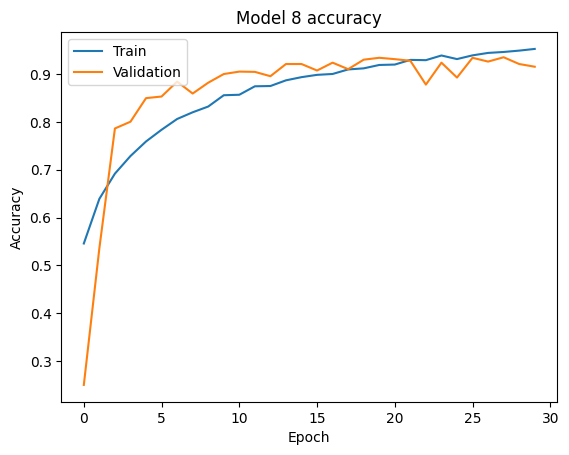

In [ ]:
# Plot training & validation accuracy values
plt.plot(history8.history['accuracy'])
plt.plot(history8.history['val_accuracy'])
plt.title('Model 8 accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

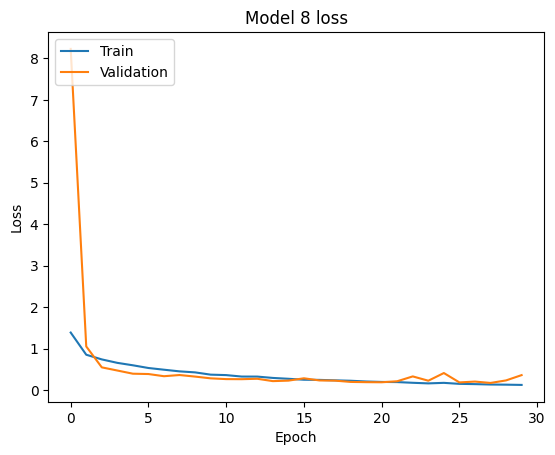

In [ ]:
# Plotting train & validation loss
plt.plot(history8.history['loss'])
plt.plot(history8.history['val_loss'])
plt.title('Model 8 loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
val_predictions8 = model8.predict(validation_ds8)
val_predicted_classes8 = np.argmax(val_predictions8, axis=1)
val_true_classes8 = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in validation_ds8])

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
print(classification_report(val_true_classes8, val_predicted_classes8, target_names=class_names))

56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step
              precision    recall  f1-score   support

      glioma       0.98      0.83      0.90       442
  meningioma       0.84      0.95      0.89       442
     notumor       0.95      0.97      0.96       441
   pituitary       0.99      1.00      0.99       442

    accuracy                           0.93      1767
   macro avg       0.94      0.93      0.93      1767
weighted avg       0.94      0.93      0.93      1767



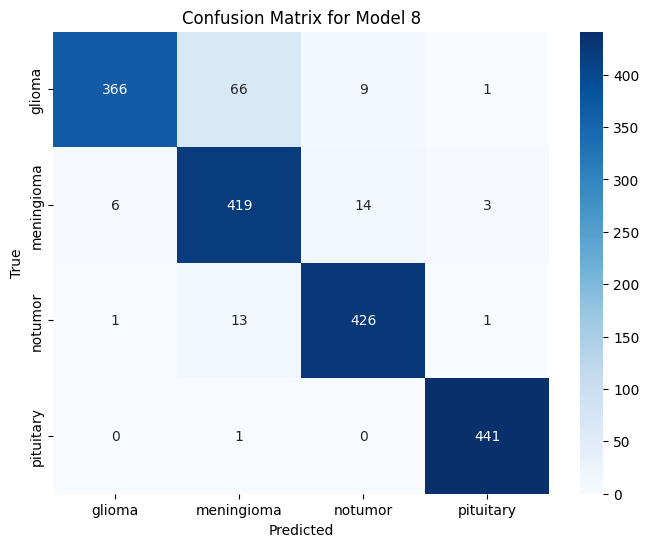

In [ ]:
cm8 = confusion_matrix(val_true_classes8, val_predicted_classes8)
plt.figure(figsize=(8, 6))
sns.heatmap(cm8, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Model 8')
plt.show()

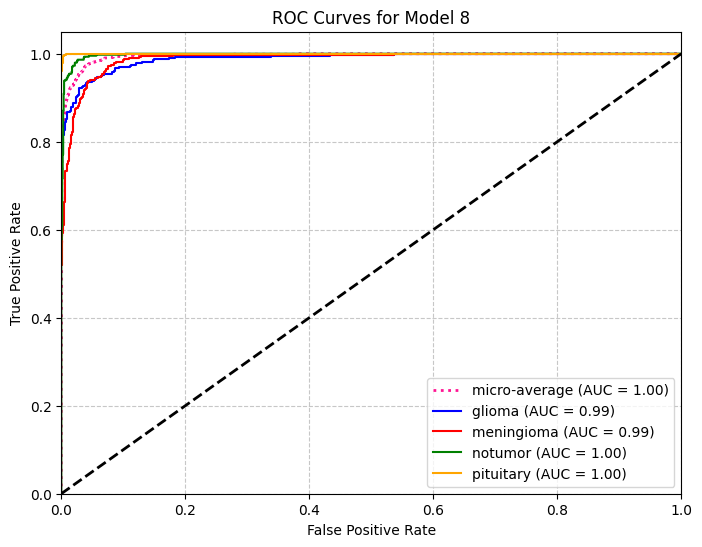

In [ ]:
# Model 8 ROC/AUC


class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(class_names)

# True labels and prediction probabilities for Model 8
y_true = val_true_classes8
y_pred_proba = val_predictions8

# Binarize true labels for one-vs-rest ROC
y_true_binarized = label_binarize(y_true, classes=range(NUM_CLASSES))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot all ROC curves
plt.figure(figsize=(8, 6))

plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=2)

colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Model 8')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Model 8 - Test Set Evaluation

In [ ]:
test_predictions8 = model8.predict(test_ds8)
test_predicted_classes8 = np.argmax(test_predictions8, axis=1)

# Get true classes from the test dataset
# The datasets are not shuffled during creation for test sets, so order should match paths.
test_true_classes8 = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds8])

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
print("Classification Report (Test Set for Model 8):")
print(classification_report(test_true_classes8, test_predicted_classes8, target_names=class_names))

70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step
Classification Report (Test Set for Model 8):
              precision    recall  f1-score   support

      glioma       0.98      0.86      0.92       552
  meningioma       0.87      0.96      0.91       552
     notumor       0.96      0.98      0.97       553
   pituitary       0.99      1.00      0.99       552

    accuracy                           0.95      2209
   macro avg       0.95      0.95      0.95      2209
weighted avg       0.95      0.95      0.95      2209



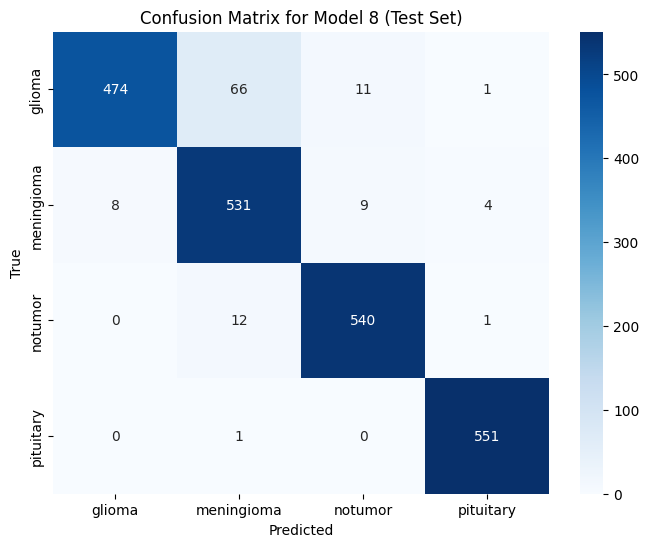

In [ ]:
cm8_test = confusion_matrix(test_true_classes8, test_predicted_classes8)
plt.figure(figsize=(8, 6))
sns.heatmap(cm8_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Model 8 (Test Set)')
plt.show()

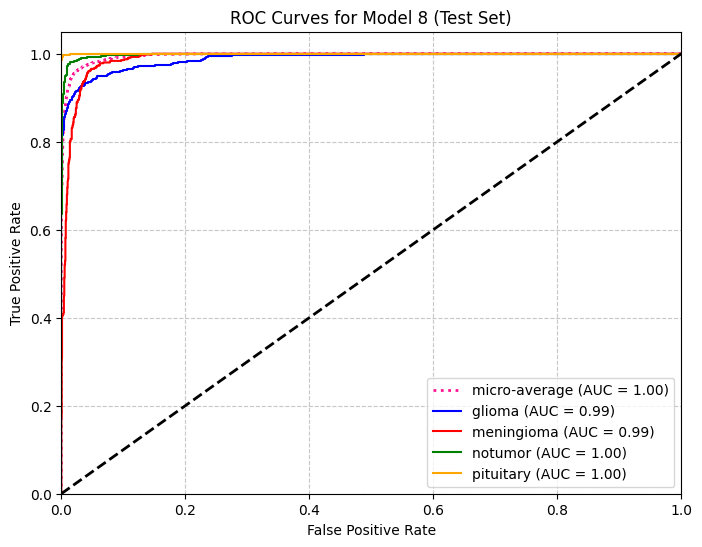

In [ ]:
# Model 8 ROC/AUC (Test Set)

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(class_names)

# True labels and prediction probabilities for Model 8
y_true = test_true_classes8
y_pred_proba = test_predictions8

# Binarize true labels for one-vs-rest ROC
y_true_binarized = label_binarize(y_true, classes=range(NUM_CLASSES))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot all ROC curves
plt.figure(figsize=(8, 6))

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=2)

# Plot individual class ROC curves
colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Plot random chance line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Model 8 (Test Set)')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

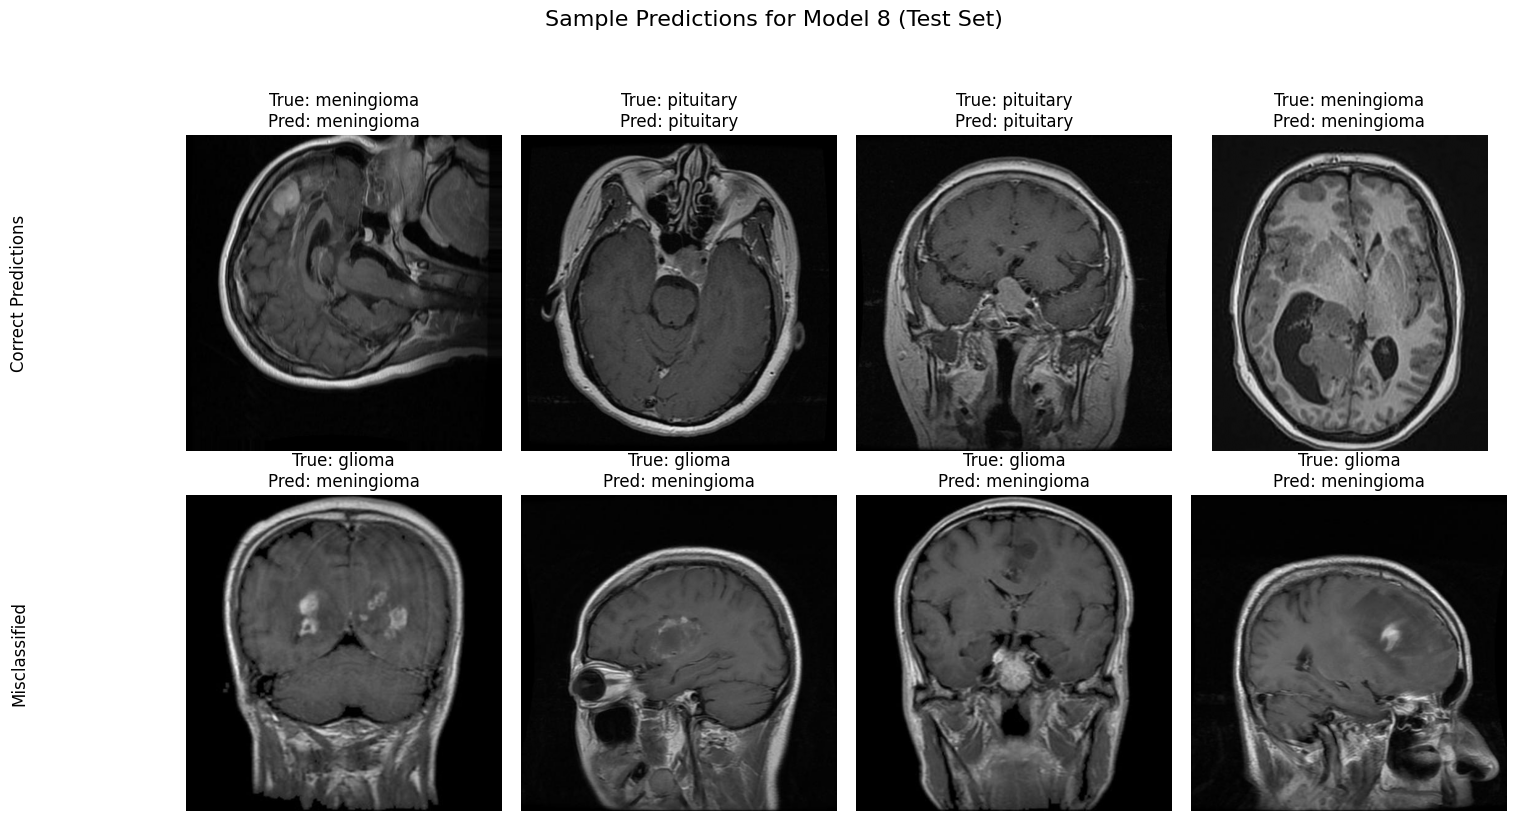

In [ ]:
# Build a grid of sample images (correctly and misclassified) for Model 8

# Reusing X_test_paths_balanced which was defined earlier for Model 8's test split
test_paths_model8 = X_test_paths_balanced

# Create a list of (path, true_label, predicted_label) for analysis
test_results_for_display_model8 = []
for i in range(len(test_paths_model8)):
    test_results_for_display_model8.append({
        'path': test_paths_model8[i],
        'true_label_idx': test_true_classes8[i],
        'predicted_label_idx': test_predicted_classes8[i]
    })

correct_examples_model8 = []
misclassified_examples_model8 = []

for item in test_results_for_display_model8:
    if item['true_label_idx'] == item['predicted_label_idx']:
        correct_examples_model8.append(item)
    else:
        misclassified_examples_model8.append(item)

# Select up to 4 correct and 4 misclassified examples
num_to_display = 4
selected_correct_model8 = correct_examples_model8[:num_to_display]
selected_misclassified_model8 = misclassified_examples_model8[:num_to_display]

fig, axes = plt.subplots(2, num_to_display, figsize=(15, 8))
fig.suptitle(f"Sample Predictions for Model 8 (Test Set)", fontsize=16, y=1.02)

# Display Correct Predictions
for i, ax in enumerate(axes[0]):
    if i < len(selected_correct_model8):
        item = selected_correct_model8[i]
        try:
            img = Image.open(item['path'])
            ax.imshow(img, cmap='gray')
            ax.set_title(f"True: {class_names[item['true_label_idx']]}\nPred: {class_names[item['predicted_label_idx']]}")
            ax.axis('off')
        except Exception as e:
            ax.set_title(f"Load Error: {e}")
            ax.axis('off')
    else:
        ax.axis('off') # Hide empty subplots

# Display Misclassified Predictions
for i, ax in enumerate(axes[1]):
    if i < len(selected_misclassified_model8):
        item = selected_misclassified_model8[i]
        try:
            img = Image.open(item['path'])
            ax.imshow(img, cmap='gray')
            ax.set_title(f"True: {class_names[item['true_label_idx']]}\nPred: {class_names[item['predicted_label_idx']]}")
            ax.axis('off')
        except Exception as e:
            ax.set_title(f"Load Error: {e}")
            ax.axis('off')
    else:
        ax.axis('off') # Hide empty subplots

axes[0, 0].text(-0.5, 0.5, "Correct Predictions", rotation=90, va='center', ha='right', transform=axes[0, 0].transAxes, fontsize=12)
axes[1, 0].text(-0.5, 0.5, "Misclassified", rotation=90, va='center', ha='right', transform=axes[1, 0].transAxes, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()